# Current SPUR process: repeat performance evaluation

**New follow-up:** the follow-up Python cells analyze `list_issues`, probe query plans, benchmark candidate SQL, test change-tracking coverage, and present the [enhancement proposal](docs/performance/2026-10-09-spur-64019/list-issues-proposal.md) with Z3 receipts. The final cell contains the [Jev compile handoff](docs/performance/2026-10-09-spur-64019/list-issues-jev-handoff.md), including six rejected regression traces.

**PID 64019 · 2026-10-09 · /Volumes/Projects/spur**

This notebook analyzes a fresh observation of the running process and compares it with the earlier PID 71291 snapshot investigation. The process and its caches were kept intact. Ambient observation is separate from an explicitly triggered sequence of 40 read-only graph requests.

The loaded executable UUID matches the installed binary, which contains the incremental graph implementation. Its exact embedded Git revision is not exposed by `spur --version`; workspace HEAD alone is not treated as build proof.

Raw data and the capture script: `docs/performance/2026-10-09-spur-64019/`. The previous notebook remains intact. All results below are computed from saved samples, not inferred from the code changes.

In [3]:
# Parse the saved native samples and resource counters directly in this Python cell.
# Each branch is converted to exclusive weight, then attributed to its inclusive path.
# macOS sample's independent collapsed-leaf totals validate the parser.
"""Reproducible analysis used by the comparison notebook (standard library)."""
from collections import Counter
import csv
import json
import math
from pathlib import Path
import re
import statistics

WAIT = re.compile(r'^(?:__psynch_(?:cvwait|mutexwait|rw_\w+)|semaphore_(?:timed)?wait_trap|'
                  r'kevent(?:64)?|__workq_kernreturn|__ulock_wait\w*|mach_msg\w*(?:trap|internal)|'
                  r'__select|select|poll|swtch_pri)$')

def symbol(frame):
    return re.split(r'\s+\(in\s', frame, maxsplit=1)[0].strip()

def stable_symbol(frame):
    return re.sub(r'::h[0-9a-f]{16}$', '', symbol(frame))

def parse_sample(path):
    text = Path(path).read_text()
    body = text.split('Call graph:\n', 1)[1].split('\nTotal number in stack', 1)[0]
    nodes, stack, roots = [], [], []
    for line in body.splitlines():
        m = re.match(r'^([ +!:|]*)(\d+) (.+)$', line)
        if not m:
            continue
        indent, count, frame = len(m[1]), int(m[2]), m[3]
        while stack and nodes[stack[-1]]['indent'] >= indent:
            stack.pop()
        parent = stack[-1] if stack else None
        node = {'indent': indent, 'count': count, 'frame': frame, 'parent': parent, 'children': []}
        index = len(nodes)
        nodes.append(node)
        if parent is None:
            assert 'Thread_' in frame, frame
            roots.append(index)
        else:
            nodes[parent]['children'].append(index)
        stack.append(index)
    total = sum(nodes[i]['count'] for i in roots)
    leaf_counts, categories, app_frames = Counter(), Counter(), Counter()
    signals = Counter()
    wait_count = exclusive_total = 0
    for node in nodes:
        weight = node['count'] - sum(nodes[i]['count'] for i in node['children'])
        assert weight >= 0, node
        if not weight:
            continue
        exclusive_total += weight
        leaf = symbol(node['frame'])
        leaf_counts[leaf] += weight
        chain = [node['frame']]
        parent = node['parent']
        while parent is not None:
            chain.append(nodes[parent]['frame'])
            parent = nodes[parent]['parent']
        inclusive = '\n'.join(chain)
        for key, token in {
            'snapshot_inclusive': 'load_graph_snapshot',
            'whole_graph_hash_inclusive': 'compute_data_hash',
            'incremental_request_inclusive': 'graph_engine::incremental::',
            'initial_load_inclusive': 'incremental::load_initial',
            'delta_load_inclusive': 'incremental::load_delta',
            'hygiene_inclusive': 'run_index_hygiene_sweep',
        }.items():
            if token in inclusive:
                signals[key] += weight
        if WAIT.match(leaf):
            wait_count += weight
            continue
        if 'load_graph_snapshot' in inclusive or 'compute_data_hash' in inclusive:
            category = 'Legacy snapshot/hash'
        elif 'graph_engine::incremental::' in inclusive:
            category = 'Incremental graph request'
        elif any(x in inclusive for x in ('spur_tui', 'ratatui', 'crossterm')):
            category = 'TUI/session work'
        elif any(x in inclusive for x in ('beads_rust', 'spur_pm::beads_crate', 'sqlite3', 'rusqlite')):
            category = 'Other beads/SQLite work'
        elif 'spur_core::plan::reconciler' in inclusive:
            category = 'Reconciler'
        else:
            category = 'Other/unresolved'
        categories[category] += weight
        caller = next((stable_symbol(f) for f in chain if 'spur_' in f or 'beads_rust' in f), '(no resolved application frame)')
        app_frames[caller] += weight
    assert exclusive_total == total
    assert sum(categories.values()) + wait_count == total
    # Independent check against macOS sample's own collapsed leaf totals.
    collapsed = text.split('Sort by top of stack, same collapsed (when >= 5):\n', 1)[1].split('\nBinary Images:', 1)[0]
    checks = 0
    for line in collapsed.splitlines():
        m = re.match(r'^\s+(.+?)\s{2,}(\d+)\s*$', line)
        if m:
            name, count = symbol(m[1]), int(m[2])
            assert leaf_counts[name] == count, (path, name, leaf_counts[name], count)
            checks += 1
    assert checks > 0
    return {
        'sample': Path(path).stem, 'threads': len(roots),
        'total_thread_observations': total, 'known_wait_observations': wait_count,
        'other_observations': total-wait_count,
        **{k: signals[k] for k in ('snapshot_inclusive', 'whole_graph_hash_inclusive',
            'incremental_request_inclusive', 'initial_load_inclusive', 'delta_load_inclusive', 'hygiene_inclusive')},
        'non_wait_categories': dict(categories),
        'top_application_frames_excluding_known_waits': app_frames.most_common(12),
        'collapsed_leaf_checks_passed': checks,
    }

def evaluate_capture(directory):
    directory = Path(directory)
    meta = json.loads((directory / 'capture.json').read_text())
    rows = list(csv.DictReader((directory / 'telemetry.csv').open()))
    factor = meta['timebase']['numer'] / meta['timebase']['denom'] / 1e9
    intervals = []
    phases = {}
    for a, b in zip(rows, rows[1:]):
        wall = float(b['elapsed_s']) - float(a['elapsed_s'])
        user = (int(b['user_time']) - int(a['user_time'])) * factor
        system = (int(b['system_time']) - int(a['system_time'])) * factor
        assert wall > 0 and user >= 0 and system >= 0
        phase = b['phase']
        intervals.append({'elapsed_s': float(b['elapsed_s']), 'phase': phase,
                          'wall_s': wall, 'user_s': user, 'system_s': system,
                          'cpu_pct': 100*(user+system)/wall})
        entry = phases.setdefault(phase, {'wall_s': 0, 'cpu_s': 0})
        entry['wall_s'] += wall
        entry['cpu_s'] += user + system
    for entry in phases.values():
        entry['avg_cpu_pct'] = 100*entry['cpu_s']/entry['wall_s']
    def changes(column):
        values = [r[column] for r in rows if r.get(column, '') != '']
        return {'values': sorted(set(map(int, values))),
                'transitions': sum(a != b for a, b in zip(values, values[1:]))}
    wall = float(rows[-1]['elapsed_s']) - float(rows[0]['elapsed_s'])
    cpu = sum(i['user_s'] + i['system_s'] for i in intervals)
    summary = {
        'pid': meta['pid'], 'wall_s': wall, 'cpu_s': cpu,
        'avg_cpu_pct': 100*cpu/wall,
        'peak_one_second_interval_cpu_pct': max(i['cpu_pct'] for i in intervals if i['wall_s'] >= 0.5),
        'db_data_version': changes('db_data_version'),
        'graph_revision': changes('graph_revision'),
        'schema_version': changes('schema_version'),
        'db_probe_errors': [r['db_probe_error'] for r in rows if r['db_probe_error']],
        'rss_start_mib': int(rows[0]['resident_size']) / 2**20,
        'rss_end_mib': int(rows[-1]['resident_size']) / 2**20,
        'footprint_start_mib': int(rows[0]['phys_footprint']) / 2**20,
        'footprint_end_mib': int(rows[-1]['phys_footprint']) / 2**20,
        'disk_read_mib': (int(rows[-1]['diskio_bytesread'])-int(rows[0]['diskio_bytesread'])) / 2**20,
        'disk_written_mib': (int(rows[-1]['diskio_byteswritten'])-int(rows[0]['diskio_byteswritten'])) / 2**20,
        'phase_metrics': phases,
        'samples': [parse_sample(p) for p in sorted(directory.glob('sample_*.txt'))],
    }
    assert not summary['db_probe_errors']
    return {'metadata': meta, 'rows': rows, 'intervals': intervals, 'summary': summary}

def evaluate_requests(path):
    payload = json.loads(Path(path).read_text())
    responses = []
    for row in payload['requests']:
        assert not row['response'].get('isError', False)
        response = json.loads(next(c['text'] for c in row['response']['content'] if c['type'] == 'text'))
        assert response['data_hash'].startswith('g2:')
        responses.append(response)
    values = sorted(r['elapsed_ms'] for r in payload['requests'])
    def percentile(p):
        x = (len(values)-1)*p
        lo, hi = math.floor(x), math.ceil(x)
        return values[lo] + (values[hi]-values[lo])*(x-lo)
    return {
        'count': len(values), 'p50_roundtrip_ms': statistics.median(values),
        'p95_roundtrip_ms': percentile(0.95), 'max_roundtrip_ms': max(values),
        'min_roundtrip_ms': min(values), 'unique_hashes': sorted({r['data_hash'] for r in responses}),
        'identical_responses': all(r == responses[0] for r in responses),
        'nodes_returned': responses[0]['nodes'], 'edges_returned': responses[0]['edges'],
        'timing_scope': payload['timing_scope'],
    }


In [6]:
from pathlib import Path
import json
from IPython.display import display, Markdown

PROJECT = next(p for p in (Path.cwd(), *Path.cwd().parents, Path("/Volumes/Projects/spur"))
               if (p / "docs/performance/2026-10-09-spur-64019/ambient/capture.json").exists())
ROOT = PROJECT / "docs/performance/2026-10-09-spur-64019"
current = evaluate_capture(ROOT / "ambient")
controlled = evaluate_capture(ROOT / "controlled")
previous = evaluate_capture(PROJECT / "docs/performance/2026-10-09-snapshot-rebuilds")
requests = evaluate_requests(ROOT / "controlled/requests.json")
old_saved = json.loads((PROJECT / "docs/performance/2026-10-09-snapshot-rebuilds/analysis.json").read_text())
assert abs(previous["summary"]["cpu_s"] - old_saved["cpu_seconds"]) < 1e-8
assert [s["snapshot_inclusive"] for s in previous["summary"]["samples"]] == [535, 516, 0]
result = {
    "current_ambient": current["summary"],
    "controlled": controlled["summary"],
    "previous_ambient": previous["summary"],
    "requests": requests,
    "interpretation_limits": [
        "Observational before/after captures are not a matched-workload benchmark.",
        "Native sample observes all threads including sleeping workers; frame counts are not call counts or CPU percentages.",
        "Absence of a stack frame does not prove zero executions.",
        "MCP round-trip timing covers transport and dispatch, not only GraphEngine.",
        "RSS and physical footprint measure different things; neither alone proves a memory leak or its resolution.",
        "Exact running git revision is not exposed; loaded UUID and incremental-path stack frames provide build/path evidence."
    ]
}
(ROOT / "analysis.json").write_text(json.dumps(result, indent=2) + "\n")
display(Markdown("### Measured process activity"))
table = ["| Capture | Wall (s) | CPU (s) | Mean CPU (% of one core) | Peak ~1s CPU (%) | Footprint end (MiB) |",
         "|---|---:|---:|---:|---:|---:|"]
for label, capture in [("Earlier PID 71291", previous), ("Current PID 64019 · ambient", current), ("Current PID 64019 · 40 graph reads", controlled)]:
    s=capture["summary"]
    table.append(f'| {label} | {s["wall_s"]:.2f} | {s["cpu_s"]:.3f} | {s["avg_cpu_pct"]:.2f} | {s["peak_one_second_interval_cpu_pct"]:.2f} | {s["footprint_end_mib"]:.1f} |')
display(Markdown("\n".join(table)))
display(Markdown("### Graph paths observed in the three ambient stack samples"))
graph_table = ["| Inclusive path | Earlier PID 71291 | Current PID 64019 |", "|---|---:|---:|"]
for title, key in [("Legacy snapshot loader", "snapshot_inclusive"), ("Whole-graph hash", "whole_graph_hash_inclusive"), ("Incremental graph request", "incremental_request_inclusive")]:
    graph_table.append(f'| {title} | {sum(s[key] for s in previous["summary"]["samples"])} | {sum(s[key] for s in current["summary"]["samples"])} |')
display(Markdown("\n".join(graph_table)))
display(Markdown(f"""### Database state and explicit graph reads

- Ambient graph revision: **{current["summary"]["graph_revision"]["values"]}**, with **{current["summary"]["graph_revision"]["transitions"]} observed transition**.
- Controlled graph revision: **{controlled["summary"]["graph_revision"]["values"]}**, with **{controlled["summary"]["db_data_version"]["transitions"]} SQLite commit-token transitions**.
- **{requests["count"]}** requests; **{len(requests["unique_hashes"])}** distinct hash; identical responses: **{requests["identical_responses"]}**.
- MCP round-trip: median **{requests["p50_roundtrip_ms"]:.1f} ms**, p95 **{requests["p95_roundtrip_ms"]:.2f} ms**, maximum **{requests["max_roundtrip_ms"]} ms**.
- Each response contains **{requests["nodes_returned"]} nodes / {requests["edges_returned"]} edge**.

SQLite data-version values are meaningful only within the same persistent connection. Stack observations are not invocation counts or CPU percentages. The controlled requests were measured separately from ambient activity.
"""))


### Measured process activity

| Capture | Wall (s) | CPU (s) | Mean CPU (% of one core) | Peak ~1s CPU (%) | Footprint end (MiB) |
|---|---:|---:|---:|---:|---:|
| Earlier PID 71291 | 53.17 | 13.027 | 24.50 | 101.87 | 3067.8 |
| Current PID 64019 · ambient | 53.14 | 2.681 | 5.04 | 43.16 | 1244.7 |
| Current PID 64019 · 40 graph reads | 14.04 | 0.552 | 3.93 | 6.75 | 1245.0 |

### Graph paths observed in the three ambient stack samples

| Inclusive path | Earlier PID 71291 | Current PID 64019 |
|---|---:|---:|
| Legacy snapshot loader | 1051 | 0 |
| Whole-graph hash | 160 | 0 |
| Incremental graph request | 0 | 6 |

### Database state and explicit graph reads

- Ambient graph revision: **[9, 15]**, with **1 observed transition**.
- Controlled graph revision: **[15]**, with **0 SQLite commit-token transitions**.
- **40** requests; **1** distinct hash; identical responses: **True**.
- MCP round-trip: median **6.0 ms**, p95 **10.85 ms**, maximum **30 ms**.
- Each response contains **2 nodes / 1 edge**.

SQLite data-version values are meaningful only within the same persistent connection. Stack observations are not invocation counts or CPU percentages. The controlled requests were measured separately from ambient activity.


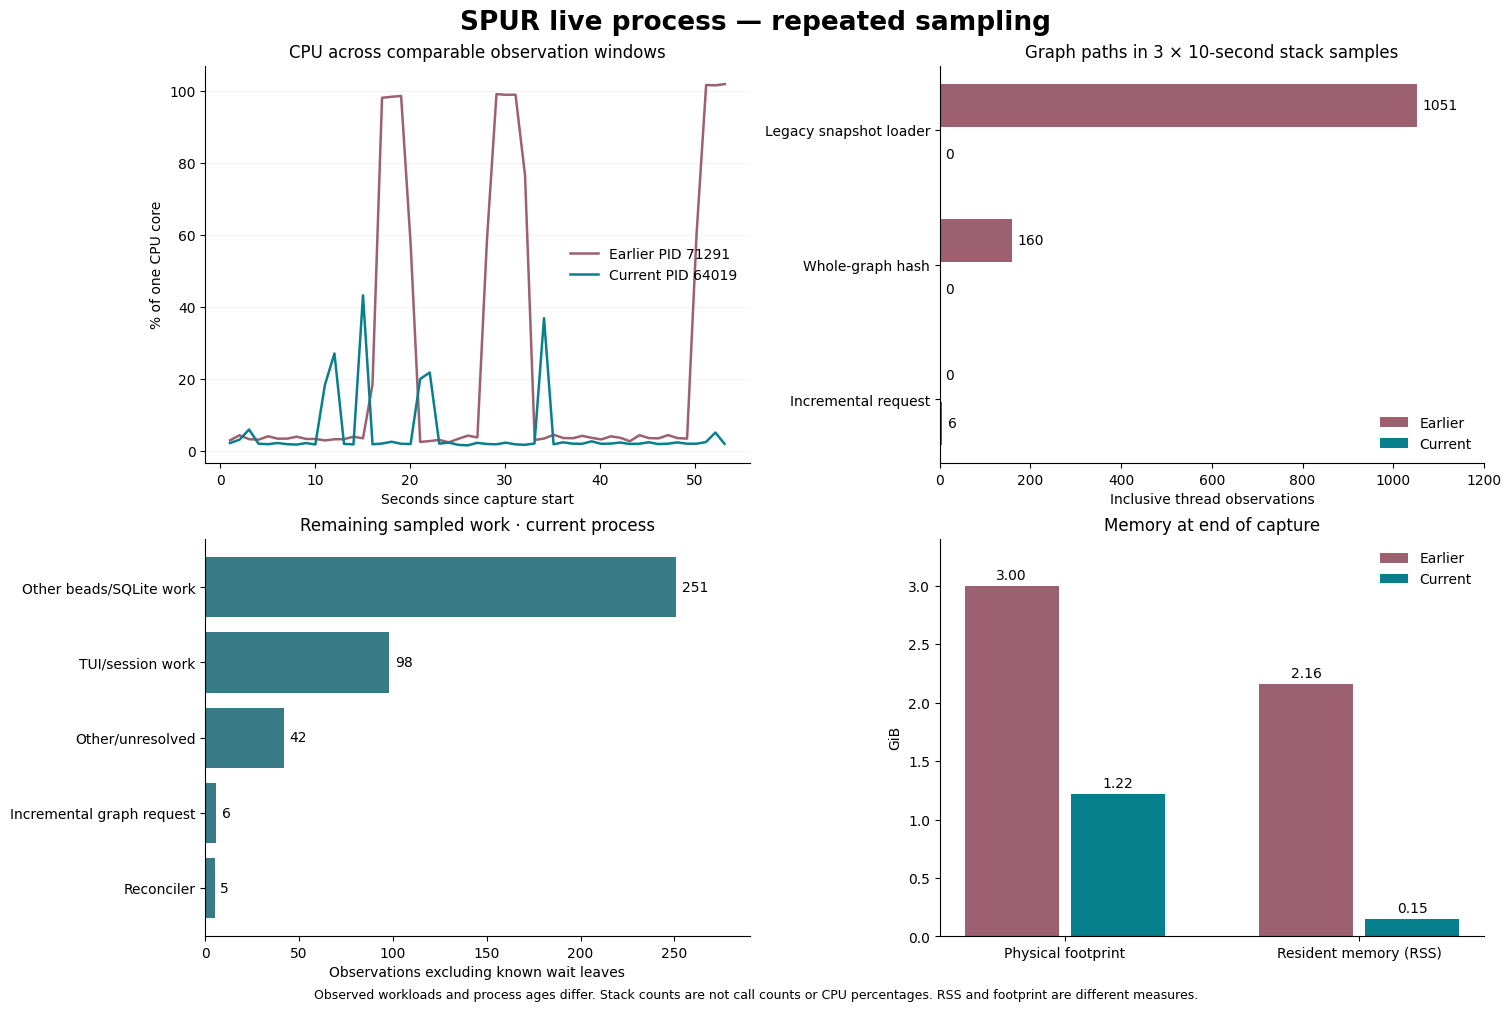

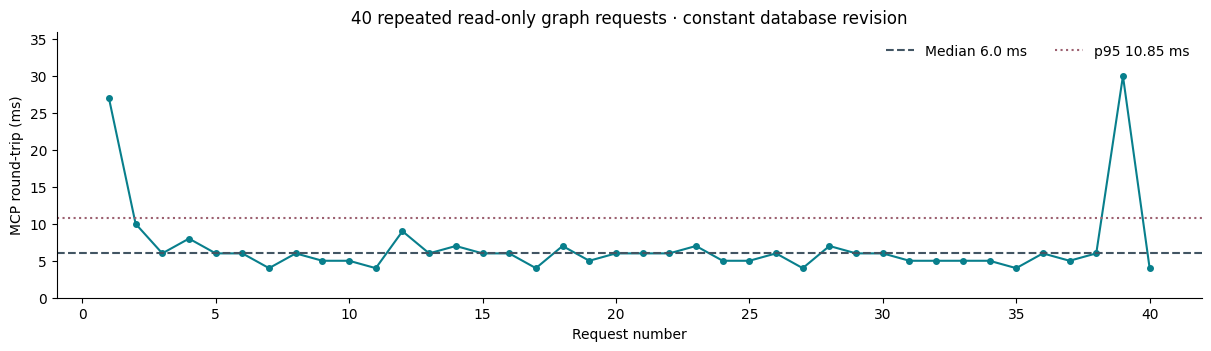

In [5]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

plt.rcParams.update({"font.size":10, "axes.spines.top":False, "axes.spines.right":False})
colors = {"Earlier":"#9c6070", "Current":"#087f8c"}
fig, axes = plt.subplots(2,2,figsize=(15,10),layout="constrained")
fig.suptitle("SPUR live process — repeated sampling", fontsize=19, weight="bold")
for label, cap in [("Earlier",previous),("Current",current)]:
    intervals=[r for r in cap["intervals"] if r["wall_s"] >= .5]
    axes[0,0].plot([r["elapsed_s"] for r in intervals], [r["cpu_pct"] for r in intervals],
                   color=colors[label], label=f'{label} PID {cap["summary"]["pid"]}', linewidth=1.8)
axes[0,0].set(title="CPU across comparable observation windows",xlabel="Seconds since capture start",ylabel="% of one CPU core")
axes[0,0].legend(frameon=False)
axes[0,0].grid(axis="y",alpha=.15)

labels=["Legacy snapshot loader","Whole-graph hash","Incremental request"]
keys=["snapshot_inclusive","whole_graph_hash_inclusive","incremental_request_inclusive"]
y=np.arange(3)
for shift,(label,cap) in zip([-.18,.18],[("Earlier",previous),("Current",current)]):
    values=[sum(s[k] for s in cap["summary"]["samples"]) for k in keys]
    bars=axes[0,1].barh(y+shift,values,height=.32,label=label,color=colors[label])
    axes[0,1].bar_label(bars,padding=4)
axes[0,1].set(yticks=y,yticklabels=labels,title="Graph paths in 3 × 10-second stack samples",xlabel="Inclusive thread observations")
axes[0,1].invert_yaxis()
axes[0,1].set_xlim(0,1200)
axes[0,1].legend(frameon=False)

counts=Counter()
for s in current["summary"]["samples"]:
    counts.update(s["non_wait_categories"])
pairs=counts.most_common()
bars=axes[1,0].barh([p[0] for p in pairs],[p[1] for p in pairs],color="#387b87")
axes[1,0].bar_label(bars,padding=4)
axes[1,0].invert_yaxis()
axes[1,0].set(title="Remaining sampled work · current process",xlabel="Observations excluding known wait leaves",xlim=(0,290))

x=np.arange(2)
for shift,(label,cap) in zip([-.18,.18],[("Earlier",previous),("Current",current)]):
    s=cap["summary"]
    vals=[s["footprint_end_mib"]/1024,s["rss_end_mib"]/1024]
    bars=axes[1,1].bar(x+shift,vals,width=.32,label=label,color=colors[label])
    axes[1,1].bar_label(bars,fmt="%.2f",padding=3)
axes[1,1].set(xticks=x,xticklabels=["Physical footprint","Resident memory (RSS)"],
              title="Memory at end of capture",ylabel="GiB",ylim=(0,3.4))
axes[1,1].legend(frameon=False)
fig.supxlabel("Observed workloads and process ages differ. Stack counts are not call counts or CPU percentages. RSS and footprint are different measures.",fontsize=9)
fig.savefig(ROOT/"comparison.png",dpi=160,bbox_inches="tight")
fig.savefig(ROOT/"comparison.svg",bbox_inches="tight")
display(fig)
plt.close(fig)

latencies=[r["elapsed_ms"] for r in json.loads((ROOT/"controlled/requests.json").read_text())["requests"]]
fig,ax=plt.subplots(figsize=(12,3.4),layout="constrained")
ax.plot(range(1,len(latencies)+1),latencies,"o-",color=colors["Current"],markersize=4)
ax.axhline(requests["p50_roundtrip_ms"],color="#425563",linestyle="--",label=f'Median {requests["p50_roundtrip_ms"]:.1f} ms')
ax.axhline(requests["p95_roundtrip_ms"],color="#9c6070",linestyle=":",label=f'p95 {requests["p95_roundtrip_ms"]:.2f} ms')
ax.set(title="40 repeated read-only graph requests · constant database revision",
       xlabel="Request number",ylabel="MCP round-trip (ms)",ylim=(0,max(latencies)*1.2))
ax.legend(frameon=False,ncol=2)
fig.savefig(ROOT/"request-latency.png",dpi=160,bbox_inches="tight")
display(fig)
plt.close(fig)


In [8]:
from datetime import datetime, timezone

now = current["summary"]
before = previous["summary"]
cpu_reduction = 100*(1-now["avg_cpu_pct"]/before["avg_cpu_pct"])
ambient_counts=Counter()
for sample in now["samples"]:
    ambient_counts.update(sample["non_wait_categories"])
old_loader=sum(s["snapshot_inclusive"] for s in before["samples"])
old_hash=sum(s["whole_graph_hash_inclusive"] for s in before["samples"])
new_loader=sum(s["snapshot_inclusive"] for s in now["samples"])
new_hash=sum(s["whole_graph_hash_inclusive"] for s in now["samples"])
incremental=sum(s["incremental_request_inclusive"] for s in now["samples"])
leaf_checks=sum(s["collapsed_leaf_checks_passed"] for cap in (previous,current,controlled) for s in cap["summary"]["samples"])

# Validate evidence rather than infer cache hits from equal hashes alone.
assert requests["count"] == 40 and requests["identical_responses"]
assert len(requests["unique_hashes"]) == 1
assert controlled["summary"]["graph_revision"]["transitions"] == 0
assert controlled["summary"]["db_data_version"]["transitions"] == 0
assert incremental > 0
assert new_loader == new_hash == 0
assert leaf_checks > 0
assert current["metadata"]["process_image_uuid"].upper() in current["metadata"]["installed_binary_uuid"]
assert {r["image_uuid"] for r in current["rows"]} == {current["metadata"]["process_image_uuid"]}
assert len({r["proc_start_abstime"] for r in current["rows"]}) == 1
checks = {
    "status":"passed",
    "collapsed_leaf_totals_checked":leaf_checks,
    "process_identity_stable":True,
    "installed_and_loaded_image_uuid_match":True,
    "previous_cpu_recalculation_matches_saved_analysis":True,
    "previous_loader_observations_match_saved_analysis":[535,516,0],
    "controlled_requests":requests["count"],
    "controlled_database_revision_constant":True,
    "incremental_path_observed":True,
    "source_of_analysis":"Executed inline Python cells via Notebook MCP",
    "recorded_utc":datetime.now(timezone.utc).isoformat(),
}
(ROOT/"verification.json").write_text(json.dumps(checks,indent=2)+"\n")
date_start=current["metadata"]["started_utc"]
findings=f"""## Evaluation

The running process is using the incremental graph path. During the new ambient capture, mean CPU was **{now["avg_cpu_pct"]:.2f}% of one core**, compared with **{before["avg_cpu_pct"]:.2f}%** in the earlier capture: **{cpu_reduction:.1f}% lower observed CPU**. This is an observational comparison, not a matched-workload speedup benchmark.

### Snapshot behavior

Across three native samples, the old capture contained **{old_loader}** inclusive observations under the snapshot loader and **{old_hash}** under whole-graph hashing. The current capture contained **{new_loader}** and **{new_hash}**, respectively, and **{incremental}** observations of the incremental graph request path.

The ambient database did change: its graph revision moved from **9 to 15**. During the separately recorded 40-request test, revision **15** and the SQLite commit token stayed constant. All responses were identical and carried one `g2:` fingerprint. Median MCP round-trip was **{requests["p50_roundtrip_ms"]:.1f} ms**, p95 **{requests["p95_roundtrip_ms"]:.2f} ms**, maximum **{requests["max_roundtrip_ms"]} ms**.

These results support graph reuse in the running build. Equal fingerprints alone do not prove cache hits, and sampled frame absence does not prove an exact rebuild count. No live cache-hit/full-build counter was exposed during this test; the earlier isolated work-counter tests provide that separate implementation evidence.

### Remaining work visible in the profile

Other beads/SQLite work accounts for **{ambient_counts["Other beads/SQLite work"]}** observations, and TUI/session work for **{ambient_counts["TUI/session work"]}**, among **{sum(ambient_counts.values())}** observations excluding known wait leaves. `SqliteStorage::list_issues` remains the main identifiable database path. Its reader-thread stacks do not identify the original asynchronous requester, so a next investigation should correlate recurring issue-list requests with their callers before choosing another optimization.

### Memory

Physical footprint ended at **{now["footprint_end_mib"]/1024:.2f} GiB**, versus **{before["footprint_end_mib"]/1024:.2f} GiB** earlier. Current RSS was **{now["rss_end_mib"]:.1f} MiB**. The gap between RSS and footprint matters: it is not evidence that total memory demand is only the RSS value. Process age, compression, and cache contents differ; this short observation does not establish a memory leak or its resolution.

### Method and limits

- Ambient capture: **{now["wall_s"]:.2f} s**, beginning **{date_start}**; 10 s baseline, three 10 s native samples requested at 5 ms, then 10 s recovery. Sampler setup/teardown adds to elapsed time.
- Controlled capture: **{controlled["summary"]["wall_s"]:.2f} s** with 40 explicit graph requests. Returned subgraph: two nodes and one edge; this does not benchmark global analytics.
- The loaded image UUID matches the installed image and the samples resolve the incremental code. `spur --version` reports 1.24.0 without an exact Git revision; workspace HEAD is not substituted for build identity.
- CPU comes from process counters converted using the machine's Mach timebase, cross-checked against `ps`. It excludes child-process CPU.
- Native sampling observes all threads, including sleepers. Counts are neither invocation counts nor CPU percentages. Known wait frames were separated; other frames are not automatically on-CPU time.
- The two ambient runs have different background activity, thread counts and process ages. Another SPUR session was also running. Notebook Python execution occurred after capture; observer transport and ordinary UI activity can still affect the process.
- **{leaf_checks} macOS collapsed-leaf totals** independently matched the parser. Original CPU and snapshot counts were reproduced from the earlier raw files.

All calculations and charts were executed in Python cells through Notebook MCP. Raw telemetry, native samples, request responses and verification receipts are preserved next to this notebook's report.
"""
display(Markdown(findings))
display(Markdown(f"**Verification passed:** {leaf_checks} collapsed-leaf checks, stable process identity, matching executable UUID, and consistent repeated graph responses."))
_ = (ROOT/"README.md").write_text("# Current SPUR process evaluation — bd-bnfro\n\n"
    + "Notebook: [spur-64019-performance-20261009.ipynb](../../../spur-64019-performance-20261009.ipynb)\n\n"
    + findings + "\n\n![Comparison](comparison.png)\n\n![Request latency](request-latency.png)\n")


## Evaluation

The running process is using the incremental graph path. During the new ambient capture, mean CPU was **5.04% of one core**, compared with **24.50%** in the earlier capture: **79.4% lower observed CPU**. This is an observational comparison, not a matched-workload speedup benchmark.

### Snapshot behavior

Across three native samples, the old capture contained **1051** inclusive observations under the snapshot loader and **160** under whole-graph hashing. The current capture contained **0** and **0**, respectively, and **6** observations of the incremental graph request path.

The ambient database did change: its graph revision moved from **9 to 15**. During the separately recorded 40-request test, revision **15** and the SQLite commit token stayed constant. All responses were identical and carried one `g2:` fingerprint. Median MCP round-trip was **6.0 ms**, p95 **10.85 ms**, maximum **30 ms**.

These results support graph reuse in the running build. Equal fingerprints alone do not prove cache hits, and sampled frame absence does not prove an exact rebuild count. No live cache-hit/full-build counter was exposed during this test; the earlier isolated work-counter tests provide that separate implementation evidence.

### Remaining work visible in the profile

Other beads/SQLite work accounts for **251** observations, and TUI/session work for **98**, among **402** observations excluding known wait leaves. `SqliteStorage::list_issues` remains the main identifiable database path. Its reader-thread stacks do not identify the original asynchronous requester, so a next investigation should correlate recurring issue-list requests with their callers before choosing another optimization.

### Memory

Physical footprint ended at **1.22 GiB**, versus **3.00 GiB** earlier. Current RSS was **151.6 MiB**. The gap between RSS and footprint matters: it is not evidence that total memory demand is only the RSS value. Process age, compression, and cache contents differ; this short observation does not establish a memory leak or its resolution.

### Method and limits

- Ambient capture: **53.14 s**, beginning **2026-10-09T06:23:30.788634+00:00**; 10 s baseline, three 10 s native samples requested at 5 ms, then 10 s recovery. Sampler setup/teardown adds to elapsed time.
- Controlled capture: **14.04 s** with 40 explicit graph requests. Returned subgraph: two nodes and one edge; this does not benchmark global analytics.
- The loaded image UUID matches the installed image and the samples resolve the incremental code. `spur --version` reports 1.24.0 without an exact Git revision; workspace HEAD is not substituted for build identity.
- CPU comes from process counters converted using the machine's Mach timebase, cross-checked against `ps`. It excludes child-process CPU.
- Native sampling observes all threads, including sleepers. Counts are neither invocation counts nor CPU percentages. Known wait frames were separated; other frames are not automatically on-CPU time.
- The two ambient runs have different background activity, thread counts and process ages. Another SPUR session was also running. Notebook Python execution occurred after capture; observer transport and ordinary UI activity can still affect the process.
- **132 macOS collapsed-leaf totals** independently matched the parser. Original CPU and snapshot counts were reproduced from the earlier raw files.

All calculations and charts were executed in Python cells through Notebook MCP. Raw telemetry, native samples, request responses and verification receipts are preserved next to this notebook's report.


**Verification passed:** 132 collapsed-leaf checks, stable process identity, matching executable UUID, and consistent repeated graph responses.

## Follow-up: why `list_issues` still appears

**Task bd-m6e3r — sample analysis and enhancement proposal.** The following Python cells reuse the saved PID 64019 ambient and controlled captures. They measure inclusive `SqliteStorage::list_issues` stacks, distinguish execution from preparation and decoding, and retain the asynchronous-caller uncertainty. Source inspection and read-only query-plan probes are separate evidence; their workload is not attributed to the earlier capture.

| Capture | Sample | list_issues observations | Excluding known waits | All other/non-wait observations |
|---|---|---:|---:|---:|
| ambient | sample_1 | 146 | 145 | 231 |
| ambient | sample_2 | 11 | 11 | 67 |
| ambient | sample_3 | 52 | 52 | 104 |
| controlled | sample_1 | 13 | 13 | 115 |

**Ambient attribution: 208 / 402 = 51.7%** of observations excluding known wait leaves were beneath `list_issues`. This is not a CPU percentage or a request count.

**Phase classification:** SQL execution / row fetch: 193, Known wait leaf: 1, SQL preparation: 13, Row decoding: 2

**Representative inclusive paths:**

- 14 observations: `Thread_3433152: beads-db-reader-0 → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → spur_pm::beads_crate::beads_db::reader_loop → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → beads_rust::storage::sqlite::SqliteStorage::list_issues → sqlite3_step → sqlite3VdbeExec → sqlite3VdbeFinishMoveto → sqlite3BtreeTableMoveto`

- 14 observations: `Thread_3433155: beads-db-reader-3 → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → spur_pm::beads_crate::beads_db::reader_loop → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → beads_rust::storage::sqlite::SqliteStorage::list_issues → sqlite3_step → sqlite3VdbeExec → sqlite3BtreeIndexMoveto`

- 11 observations: `Thread_3433154: beads-db-reader-2 → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → spur_pm::beads_crate::beads_db::reader_loop → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → beads_rust::storage::sqlite::SqliteStorage::list_issues → sqlite3_step → sqlite3VdbeExec → sqlite3BtreeIndexMoveto`

- 9 observations: `Thread_3433153: beads-db-reader-1 → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → spur_pm::beads_crate::beads_db::reader_loop → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → beads_rust::storage::sqlite::SqliteStorage::list_issues → sqlite3_step → sqlite3VdbeExec → sqlite3VdbeFinishMoveto → sqlite3BtreeTableMoveto`

- 9 observations: `Thread_3433153: beads-db-reader-1 → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → spur_pm::beads_crate::beads_db::reader_loop → core::ops::function::FnOnce::call_once$u7b$$u7b$vtable.shim$u7d$$u7d$ → beads_rust::storage::sqlite::SqliteStorage::list_issues → sqlite3_step → sqlite3VdbeExec → sqlite3BtreeIndexMoveto`

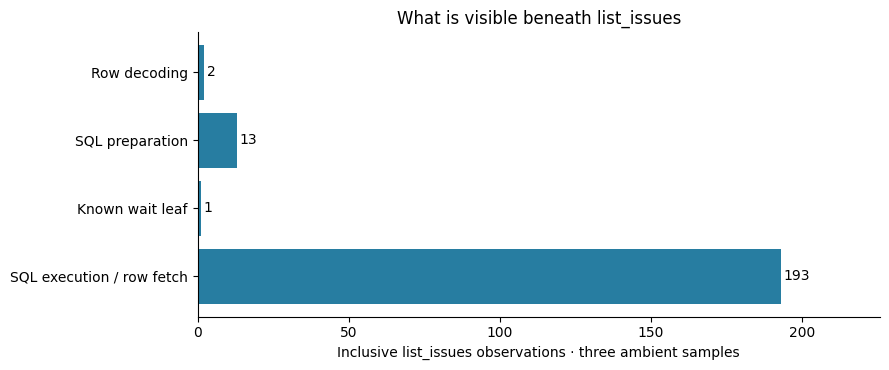

In [9]:
# Inclusive attribution beneath list_issues; weights are observations, never call counts.
from collections import Counter
import re, json
from pathlib import Path
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

def list_issue_profile(path):
    text = path.read_text()
    body = text.split("Call graph:\n",1)[1].split("\nTotal number in stack",1)[0]
    nodes, stack = [], []
    for line in body.splitlines():
        m = re.match(r"^([ +!:|]*)(\d+) (.+)$", line)
        if not m: continue
        indent, count, frame = len(m[1]), int(m[2]), m[3]
        while stack and nodes[stack[-1]]["indent"] >= indent: stack.pop()
        parent = stack[-1] if stack else None
        nodes.append(dict(indent=indent,count=count,frame=frame,parent=parent,children=[]))
        i = len(nodes)-1
        if parent is not None: nodes[parent]["children"].append(i)
        stack.append(i)
    phases, leaves, application, roots, chains = Counter(),Counter(),Counter(),Counter(),Counter()
    total = wait = matched = matched_wait = 0
    for i,n in enumerate(nodes):
        weight=n["count"]-sum(nodes[c]["count"] for c in n["children"])
        assert weight>=0
        if not weight: continue
        total+=weight
        chain=[]
        while i is not None:
            chain.append(nodes[i]["frame"]); i=nodes[i]["parent"]
        leaf=stable_symbol(chain[0])
        is_wait=bool(WAIT.match(symbol(chain[0])))
        wait+=weight*is_wait
        if not any("SqliteStorage::list_issues" in f for f in chain): continue
        matched+=weight; matched_wait+=weight*is_wait
        roots[chain[-1]]+=weight
        leaves[leaf]+=weight
        joined="\n".join(chain)
        if is_wait: phase="Known wait leaf"
        elif any(t in joined for t in ("sqlite3_prepare","sqlite3LockAndPrepare","sqlite3Prepare")): phase="SQL preparation"
        elif any(t in joined for t in ("sqlite3_step","sqlite3Step","sqlite3VdbeExec")): phase="SQL execution / row fetch"
        elif any(t in joined for t in ("row_to_issue","from_row","parse_from_rfc3339")): phase="Row decoding"
        else: phase="Other under list_issues"
        phases[phase]+=weight
        application[next((stable_symbol(f) for f in chain if "spur_" in f or "beads_rust" in f),"(none)")]+=weight
        # Keep only named application/SQLite frames plus thread identity for inspectable ancestry.
        relevant=[stable_symbol(f) for f in reversed(chain) if any(t in f for t in ("spur_","beads_rust","sqlite3","Thread_","FnOnce"))]
        chains[" → ".join(relevant)]+=weight
    baseline=parse_sample(path)
    assert total==baseline["total_thread_observations"]
    assert total-wait==baseline["other_observations"]
    assert sum(phases.values())==matched
    return dict(sample=path.stem,total=total,non_wait=total-wait,list_inclusive=matched,
                list_non_wait=matched-matched_wait,phases=dict(phases),
                top_leaves=leaves.most_common(15),application=application.most_common(10),
                threads=dict(roots),top_chains=chains.most_common(10))

li_profiles={mode:[list_issue_profile(p) for p in sorted((ROOT/mode).glob("sample_*.txt"))]
             for mode in ("ambient","controlled")}
li_total=sum(x["list_non_wait"] for x in li_profiles["ambient"])
li_denominator=sum(x["non_wait"] for x in li_profiles["ambient"])
li_phases=Counter()
for p in li_profiles["ambient"]: li_phases.update(p["phases"])
li_report=dict(captures=li_profiles,ambient_list_non_wait=li_total,
               ambient_non_wait=li_denominator,ambient_share_non_wait_pct=100*li_total/li_denominator,
               caveat="All-thread native sampling; non-wait classification is not proof of on-CPU execution. Async reader stacks do not identify the submitting caller.")
_=(ROOT/"list-issues-analysis.json").write_text(json.dumps(li_report,indent=2)+"\n")
table=["| Capture | Sample | list_issues observations | Excluding known waits | All other/non-wait observations |",
       "|---|---|---:|---:|---:|"]
for mode,profiles in li_profiles.items():
    for p in profiles: table.append(f'| {mode} | {p["sample"]} | {p["list_inclusive"]} | {p["list_non_wait"]} | {p["non_wait"]} |')
display(Markdown("\n".join(table)))
display(Markdown(f"**Ambient attribution: {li_total} / {li_denominator} = {100*li_total/li_denominator:.1f}%** of observations excluding known wait leaves were beneath `list_issues`. This is not a CPU percentage or a request count."))
display(Markdown("**Phase classification:** "+", ".join(f"{k}: {v}" for k,v in li_phases.items())))
display(Markdown("**Representative inclusive paths:**\n\n"+"\n\n".join(f"- {count} observations: `{chain}`" for chain,count in li_profiles["ambient"][0]["top_chains"][:5])))
fig,ax=plt.subplots(figsize=(9,3.8))
labels=list(li_phases); values=[li_phases[k] for k in labels]
ax.barh(labels,values,color="#277da1")
for i,v in enumerate(values): ax.text(v+1,i,str(v),va="center")
ax.set_xlabel("Inclusive list_issues observations · three ambient samples")
ax.set_title("What is visible beneath list_issues")
ax.set_xlim(0,max(values)*1.17)
fig.tight_layout()
fig.savefig(ROOT/"list-issues-breakdown.png",dpi=160,bbox_inches="tight")
display(fig); plt.close(fig)


In [10]:
# Query-plan evidence uses a consistent private copy; no DDL is sent to the live database.
import sqlite3, time
from datetime import datetime, timezone

live_db=PROJECT/".beads/beads.db"
probe_started=datetime.now(timezone.utc).isoformat()
live=sqlite3.connect(live_db.as_uri()+"?mode=ro",uri=True,timeout=2)
probe_db=sqlite3.connect(":memory:")
deadline=time.monotonic()+15
def backup_guard(status,remaining,total):
    if time.monotonic()>deadline: raise TimeoutError("Read-only database copy exceeded 15 seconds")
try:
    live.backup(probe_db,pages=256,progress=backup_guard,sleep=0.02)
finally:
    live.close()
probe_db.execute("PRAGMA query_only=ON")
db_indexes=probe_db.execute("SELECT name,sql FROM sqlite_master WHERE type='index' AND tbl_name IN ('issues','labels')").fetchall()
db_scale=probe_db.execute("SELECT status,COUNT(*) FROM issues GROUP BY status ORDER BY status").fetchall()
source_columns="""id, content_hash, title, description, design, acceptance_criteria, notes,
status, priority, issue_type, assignee, owner, estimated_minutes,
created_at, created_by, updated_at, closed_at, close_reason, closed_by_session,
due_at, defer_until, external_ref, source_system, source_repo,
deleted_at, deleted_by, delete_reason, original_type,
compaction_level, compacted_at, compacted_at_commit, original_size,
sender, ephemeral, pinned, is_template"""
summary_columns="id,title,description,status,priority,issue_type,assignee"
template_predicate="(is_template = 0 OR is_template IS NULL)"
list_queries={
 "open_all":(f"SELECT {source_columns} FROM issues WHERE 1=1 AND status IN (?) AND {template_predicate} ORDER BY priority ASC,created_at DESC",("open",)),
 "open_200":(f"SELECT {source_columns} FROM issues WHERE 1=1 AND status IN (?) AND {template_predicate} ORDER BY priority ASC,created_at DESC LIMIT ?",("open",200)),
 "plan_label":(f"SELECT {source_columns} FROM issues WHERE 1=1 AND {template_predicate} AND EXISTS (SELECT 1 FROM labels WHERE labels.issue_id=issues.id AND labels.label=?) ORDER BY priority ASC,created_at DESC",("delegation_plan",)),
}
plans={name:[r[3] for r in probe_db.execute("EXPLAIN QUERY PLAN "+sql,args)] for name,(sql,args) in list_queries.items()}
schema_probe={
 "captured_utc":probe_started,"source":"consistent in-memory SQLite backup opened from mode=ro source",
 "python_sqlite_version":sqlite3.sqlite_version,"graph_revision":probe_db.execute("SELECT revision FROM spur_graph_clock").fetchone()[0],
 "status_counts":dict(db_scale),"indexes":[dict(name=n,sql=s) for n,s in db_indexes],
 "queries":{n:dict(sql=s,params=a,plan=plans[n]) for n,(s,a) in list_queries.items()},
 "limits":"Representative SQL shapes from pinned beads_rust source; this does not identify which filters the sampled process used."
}
_=(ROOT/"list-issues-query-plans.json").write_text(json.dumps(schema_probe,indent=2)+"\n")
display(Markdown("**Database scale at probe time:** "+", ".join(f"{status}: {n}" for status,n in db_scale)+f". Python SQLite {sqlite3.sqlite_version}."))
display(Markdown("| Query shape | Query plan |\n|---|---|\n"+"\n".join(f"| {n} | {'; '.join(p)} |" for n,p in plans.items())))
display(Markdown("**Existing indexes:**\n\n"+"\n".join(f"- `{n}`: `{s}`" for n,s in db_indexes if s)))


**Database scale at probe time:** blocked: 2, closed: 1899, in_progress: 34, open: 396. Python SQLite 3.53.1.

| Query shape | Query plan |
|---|---|
| open_all | SEARCH issues USING INDEX idx_issues_status (status=?); USE TEMP B-TREE FOR ORDER BY |
| open_200 | SEARCH issues USING INDEX idx_issues_status (status=?); USE TEMP B-TREE FOR ORDER BY |
| plan_label | SCAN issues USING INDEX idx_issues_priority_created_at; SEARCH labels EXISTS USING COVERING INDEX sqlite_autoindex_labels_1 (issue_id=? AND label=?) |

**Existing indexes:**

- `idx_issues_status`: `CREATE INDEX idx_issues_status ON issues(status)`
- `idx_issues_priority`: `CREATE INDEX idx_issues_priority ON issues(priority)`
- `idx_issues_issue_type`: `CREATE INDEX idx_issues_issue_type ON issues(issue_type)`
- `idx_issues_assignee`: `CREATE INDEX idx_issues_assignee ON issues(assignee) WHERE assignee IS NOT NULL`
- `idx_issues_created_at`: `CREATE INDEX idx_issues_created_at ON issues(created_at)`
- `idx_issues_updated_at`: `CREATE INDEX idx_issues_updated_at ON issues(updated_at)`
- `idx_issues_content_hash`: `CREATE INDEX idx_issues_content_hash ON issues(content_hash)`
- `idx_issues_external_ref`: `CREATE INDEX idx_issues_external_ref ON issues(external_ref) WHERE external_ref IS NOT NULL`
- `idx_issues_external_ref_unique`: `CREATE UNIQUE INDEX idx_issues_external_ref_unique ON issues(external_ref) WHERE external_ref IS NOT NULL`
- `idx_issues_ephemeral`: `CREATE INDEX idx_issues_ephemeral ON issues(ephemeral) WHERE ephemeral = 1`
- `idx_issues_pinned`: `CREATE INDEX idx_issues_pinned ON issues(pinned) WHERE pinned = 1`
- `idx_issues_tombstone`: `CREATE INDEX idx_issues_tombstone ON issues(status) WHERE status = 'tombstone'`
- `idx_issues_due_at`: `CREATE INDEX idx_issues_due_at ON issues(due_at) WHERE due_at IS NOT NULL`
- `idx_issues_defer_until`: `CREATE INDEX idx_issues_defer_until ON issues(defer_until) WHERE defer_until IS NOT NULL`
- `idx_issues_ready`: `CREATE INDEX idx_issues_ready
        ON issues(status, priority, created_at)
        WHERE status IN ('open', 'in_progress')
        AND ephemeral = 0
        AND pinned = 0
        AND (is_template = 0 OR is_template IS NULL)`
- `idx_labels_label`: `CREATE INDEX idx_labels_label ON labels(label)`
- `idx_labels_issue`: `CREATE INDEX idx_labels_issue ON labels(issue_id)`
- `idx_issues_priority_created_at`: `CREATE INDEX idx_issues_priority_created_at ON issues(priority ASC, created_at DESC)`

| Query variant | Rows | Median (ms) | Min–max (ms) |
|---|---:|---:|---:|
| open_all/existing | 396 | 1.906 | 1.823–1.994 |
| open_all/status_order_index | 396 | 1.671 | 1.628–1.745 |
| open_all/summary_only | 396 | 0.693 | 0.653–0.740 |
| open_200/existing | 200 | 1.796 | 1.709–1.886 |
| open_200/status_order_index | 200 | 0.859 | 0.821–0.923 |
| open_200/summary_only | 200 | 1.058 | 1.034–1.264 |
| plan_label/exists | 0 | 1.130 | 1.092–1.292 |
| plan_label/id_subquery | 0 | 0.008 | 0.007–0.012 |

**Candidate plans:**

- `open_all/status_order_index`: SEARCH issues USING INDEX candidate_status_order (status=?)

- `open_all/summary_only`: SEARCH issues USING INDEX idx_issues_status (status=?); USE TEMP B-TREE FOR ORDER BY

- `open_200/status_order_index`: SEARCH issues USING INDEX candidate_status_order (status=?)

- `open_200/summary_only`: SEARCH issues USING INDEX idx_issues_status (status=?); USE TEMP B-TREE FOR ORDER BY

- `plan_label/exists`: SCAN issues USING INDEX idx_issues_priority_created_at; SEARCH labels EXISTS USING COVERING INDEX sqlite_autoindex_labels_1 (issue_id=? AND label=?)

- `plan_label/id_subquery`: SEARCH issues USING INDEX sqlite_autoindex_issues_1 (id=?); LIST SUBQUERY 1; SEARCH labels USING INDEX idx_labels_label (label=?); USE TEMP B-TREE FOR ORDER BY

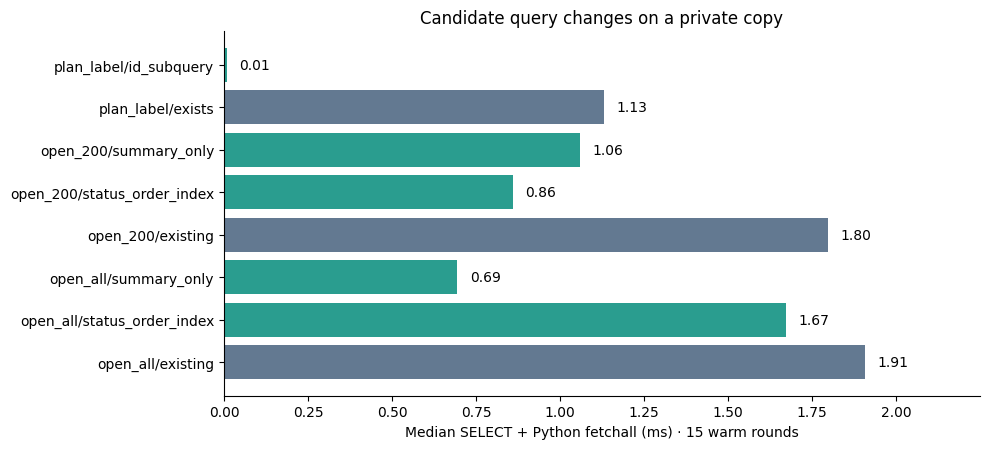

In [11]:
# Randomized, interleaved SQL-only microbenchmark on identical private database copies.
import random, statistics
candidate_db=sqlite3.connect(":memory:")
probe_db.backup(candidate_db)
candidate_db.execute("CREATE INDEX candidate_status_order ON issues(status,priority ASC,created_at DESC)")
candidate_db.commit()
candidate_db.execute("PRAGMA query_only=ON")
bench_cases={}
for q in ("open_all","open_200"):
    sql,args=list_queries[q]
    bench_cases[q+"/existing"]=(probe_db,sql,args)
    bench_cases[q+"/status_order_index"]=(candidate_db,sql,args)
    bench_cases[q+"/summary_only"]=(probe_db,sql.replace(source_columns,summary_columns),args)
sql,args=list_queries["plan_label"]
bench_cases["plan_label/exists"]=(probe_db,sql,args)
bench_cases["plan_label/id_subquery"]=(probe_db,sql.replace(
    "EXISTS (SELECT 1 FROM labels WHERE labels.issue_id=issues.id AND labels.label=?)",
    "id IN (SELECT issue_id FROM labels WHERE label=?)"),args)
bench_plans={n:[r[3] for r in db.execute("EXPLAIN QUERY PLAN "+sql,args)] for n,(db,sql,args) in bench_cases.items()}
def fetch_case(name):
    db,sql,args=bench_cases[name]
    return db.execute(sql,args).fetchall()
bench_reference={n:fetch_case(n) for n in bench_cases}
# Index/rewrite must preserve complete rows; summary projection preserves every selected field.
for q in ("open_all","open_200"):
    a=bench_reference[q+"/existing"]; b=bench_reference[q+"/status_order_index"]
    assert Counter(a)==Counter(b), "Index changed returned rows"
    positions=[x.strip() for x in source_columns.split(",")]
    selected=[positions.index(x) for x in summary_columns.split(",")]
    assert Counter(tuple(row[i] for i in selected) for row in a)==Counter(bench_reference[q+"/summary_only"])
assert Counter(bench_reference["plan_label/exists"])==Counter(bench_reference["plan_label/id_subquery"])
bench_raw={n:[] for n in bench_cases}
rng=random.Random(64019)
bench_deadline=time.perf_counter()+30
for iteration in range(15):
    order=list(bench_cases); rng.shuffle(order)
    for n in order:
        if time.perf_counter()>bench_deadline: raise TimeoutError("SQL benchmark exceeded 30 seconds")
        start=time.perf_counter_ns(); rows=fetch_case(n); elapsed=(time.perf_counter_ns()-start)/1e6
        assert len(rows)==len(bench_reference[n])
        bench_raw[n].append(elapsed)
        del rows
bench_summary={}
for n,values in bench_raw.items():
    bench_summary[n]={"rows":len(bench_reference[n]),"median_ms":statistics.median(values),
                      "min_ms":min(values),"max_ms":max(values),"rounds":len(values),"plan":bench_plans[n]}
benchmark={"method":"15 warm rounds per case, deterministic shuffled order per round; SELECT+fetchall, statement caching enabled; consistent in-memory copies; Python SQLite runtime",
           "version":sqlite3.sqlite_version,"captured_utc":datetime.now(timezone.utc).isoformat(),
           "summary":bench_summary,"raw_ms":bench_raw,"equivalence":"Complete-row multisets match for index/rewrite; projected-row multisets match for summary query.",
           "limitations":["Not a Rust adapter or live caller benchmark; excludes labels fetch, Rust decoding, queue delay and disk I/O.",
                          "Probe-time database differs from saved sample time.",
                          "Existing ORDER BY has no unique tie-breaker; equality on this dataset does not prove stable pagination on all inputs.",
                          "Narrow summary retains description because the current IssueSummary API includes it.",
                          "No measured end-to-end SPUR CPU reduction is inferred from these timings."]}
_=(ROOT/"list-issues-sql-benchmark.json").write_text(json.dumps(benchmark,indent=2)+"\n")
table=["| Query variant | Rows | Median (ms) | Min–max (ms) |","|---|---:|---:|---:|"]
for n,s in bench_summary.items(): table.append(f'| {n} | {s["rows"]} | {s["median_ms"]:.3f} | {s["min_ms"]:.3f}–{s["max_ms"]:.3f} |')
display(Markdown("\n".join(table)))
display(Markdown("**Candidate plans:**\n\n"+"\n\n".join(f"- `{n}`: {'; '.join(p)}" for n,p in bench_plans.items() if "existing" not in n)))
fig,ax=plt.subplots(figsize=(10,4.6))
names=list(bench_summary); values=[bench_summary[n]["median_ms"] for n in names]
ax.barh(names,values,color=["#637991" if n.endswith(("existing","exists")) else "#2a9d8f" for n in names])
for i,v in enumerate(values): ax.text(v+max(values)*.02,i,f"{v:.2f}",va="center")
ax.set_xlim(0,max(values)*1.18); ax.set_xlabel("Median SELECT + Python fetchall (ms) · 15 warm rounds")
ax.set_title("Candidate query changes on a private copy")
fig.tight_layout(); fig.savefig(ROOT/"list-issues-sql-benchmark.png",dpi=160,bbox_inches="tight")
display(fig); plt.close(fig)
del bench_reference


In [12]:
# Check label selectivity and graph-clock coverage on the private copy only.
label_counts=probe_db.execute("SELECT label,COUNT(*) FROM labels GROUP BY label ORDER BY COUNT(*) DESC,label").fetchall()
assert label_counts
label_cases={"no_match":("delegation_plan",0),"broad":label_counts[0],
             "sparse":next((r for r in reversed(label_counts) if r[1]>0),label_counts[-1])}
label_bench={}
base_sql=list_queries["plan_label"][0]
rewritten=base_sql.replace("EXISTS (SELECT 1 FROM labels WHERE labels.issue_id=issues.id AND labels.label=?)",
                          "id IN (SELECT issue_id FROM labels WHERE label=?)")
for shape,(label,count) in label_cases.items():
    values={"exists":[],"id_subquery":[]}; outputs={}
    for iteration in range(15):
        order=["exists","id_subquery"]; rng.shuffle(order)
        for name in order:
            sql=base_sql if name=="exists" else rewritten
            start=time.perf_counter_ns(); result_rows=probe_db.execute(sql,(label,)).fetchall()
            values[name].append((time.perf_counter_ns()-start)/1e6)
            outputs[name]=result_rows
    assert Counter(outputs["exists"])==Counter(outputs["id_subquery"])
    label_bench[shape]={"label":label,"label_links":count,"returned_rows":len(outputs["exists"]),
                       "median_ms":{n:statistics.median(v) for n,v in values.items()},"raw_ms":values}

# A description-only external SQL edit is observable by list_issues but absent from graph clock fields.
# Roll back even if an assertion fails; source database was opened read-only and is already closed.
candidate_db.execute("PRAGMA query_only=OFF")
candidate_db.execute("SAVEPOINT graph_clock_coverage")
try:
    issue_id=candidate_db.execute("SELECT id FROM issues LIMIT 1").fetchone()[0]
    before_rev=candidate_db.execute("SELECT revision FROM spur_graph_clock").fetchone()[0]
    candidate_db.execute("UPDATE issues SET description=COALESCE(description,'') || ? WHERE id=?",("\nprobe-only",issue_id))
    after_rev=candidate_db.execute("SELECT revision FROM spur_graph_clock").fetchone()[0]
    graph_clock_covers_description=(after_rev!=before_rev)
finally:
    candidate_db.execute("ROLLBACK TO graph_clock_coverage")
    candidate_db.execute("RELEASE graph_clock_coverage")
    candidate_db.execute("PRAGMA query_only=ON")
assert not graph_clock_covers_description
li_extended={"label_selectivity":label_bench,"description_only_edit_advances_graph_clock":graph_clock_covers_description,
             "scope":"Private probe database only; direct SQL edit holds updated_at/content_hash unchanged. Not a claim about normal adapter writes."}
_=(ROOT/"list-issues-coverage-probe.json").write_text(json.dumps(li_extended,indent=2)+"\n")
display(Markdown("| Label shape | Matching issues | EXISTS median (ms) | ID subquery median (ms) |\n|---|---:|---:|---:|\n"+
    "\n".join(f'| {shape} | {v["returned_rows"]} | {v["median_ms"]["exists"]:.3f} | {v["median_ms"]["id_subquery"]:.3f} |' for shape,v in label_bench.items())))
display(Markdown("**Coverage counterexample reproduced:** a description-only external SQL edit changes a list-summary field without advancing the graph revision. A general issue-list cache must use a broader revision or change feed; the existing graph clock alone is insufficient."))


| Label shape | Matching issues | EXISTS median (ms) | ID subquery median (ms) |
|---|---:|---:|---:|
| no_match | 0 | 1.039 | 0.007 |
| broad | 1427 | 7.969 | 20.638 |
| sparse | 1 | 1.109 | 0.015 |

**Coverage counterexample reproduced:** a description-only external SQL edit changes a list-summary field without advancing the graph revision. A general issue-list cache must use a broader revision or change feed; the existing graph clock alone is insufficient.

In [13]:
# Load actual solver receipts and compute a bounded independent policy cross-check.
import itertools
proofs=json.loads((ROOT/"list-issues-solver-receipts.json").read_text())
by_case={x["case"]:x for x in proofs["invocations"]}
assert by_case["protocol"]["result"]["status"]=="sat"
assert by_case["protocol"]["result"]["outcome"]=="pass"
assert by_case["badprotocol"]["result"]["status"]=="unsat"
assert by_case["old_members_only"]["result"]["status"]=="sat"
assert by_case["old_or_new_members"]["result"]["status"]=="unsat"
assert by_case["feasible"]["result"]["status"]=="sat"
policy_cases=bad_old=bad_new=0
for old_member,new_member,old_value,new_value,same_scope,coverage in itertools.product(
        [False,True],[False,True],range(3),range(3),[False,True],[False,True]):
    before=old_value if old_member else -1
    after=new_value if new_member else -1
    changed=(old_member!=new_member or old_value!=new_value)
    reuse_old=same_scope and coverage and not(old_member and changed)
    reuse_new=same_scope and coverage and not((old_member or new_member) and changed)
    bad_old+=int(reuse_old and before!=after)
    bad_new+=int(reuse_new and before!=after)
    policy_cases+=1
assert bad_old>0 and bad_new==0
def med(name): return bench_summary[name]["median_ms"]
proposal=f"""# Proposal: reduce recurring issue-list work — bd-m6e3r

Recommendation: measure callers, land the status-plus-order index as a small first change, then add a direct summary query and selective incremental reuse for recurring queries. Re-profile each step independently.

## What the notebook establishes

The saved PID 64019 ambient capture contains **{li_total}/{li_denominator} ({100*li_total/li_denominator:.1f}%)** observations beneath `SqliteStorage::list_issues` among frames excluding known wait leaves. Inclusive total is 209: **193** SQL execution/row fetch, **13** preparation, **2** decoding and **1** known wait. Counts are not calls or CPU percentages. Four beads reader threads appear; their boxed closures do not reveal the submitting async caller.

The read-only probe copied the database into memory at {schema_probe["captured_utc"]}: **{sum(schema_probe["status_counts"].values())} issues**, including **{schema_probe["status_counts"]["open"]} open**. The installed priority/creation index does not prevent the tested status-filtered query from choosing `idx_issues_status` plus a temporary sort.

| Candidate | Existing median | Candidate median | Evidence |
|---|---:|---:|---|
| Status/order index, open LIMIT 200 | {med("open_200/existing"):.3f} ms | {med("open_200/status_order_index"):.3f} ms | 200 identical rows; temp sort removed |
| Status/order index, all open | {med("open_all/existing"):.3f} ms | {med("open_all/status_order_index"):.3f} ms | 396 identical rows; temp sort removed |
| Summary projection, all open | {med("open_all/existing"):.3f} ms | {med("open_all/summary_only"):.3f} ms | Preserves selected summary fields, including description |

These are 15-round warm Python SQLite {sqlite3.sqlite_version} SELECT+fetchall measurements on private copies. They exclude Rust decoding, label loading, read-queue latency and live disk I/O. They do not predict whole-process speedup. Source pin: beads_rust `47b3b39a54b04c7d51d735c032c82e891c2a0db8`.

## Ordered implementation proposal

1. **Expose the real callers.** Carry a caller tag and tracing span through `BeadsDb::submit_read` into its reader job. Record queue wait, SQL/decoding/label duration, row count, query-shape fingerprint and cache/delta counters. Avoid issue bodies and free-text filter values in labels. Distinguish poll, UI refresh, hygiene, plan lookup and user MCP traffic. This closes the largest attribution gap before expensive changes.

2. **Add the status/order index in spur-pm.** Extend the existing connection-open index helper with `issues(status, priority ASC, created_at DESC)`. The tested single-status predicate can then filter and return ordered rows without a temp sort, and LIMIT can stop early. Keep existing indexes needed by other shapes. Verify using the same SQLite build linked by Rust, and measure index size plus insert/update overhead before retaining it. Test ties and pagination: current ordering lacks an ID tie-breaker, so changing the plan may change unspecified tie order. Treat any contract change to stable ordering separately.

3. **Return summaries directly.** Replace full 36-column Issue decoding with a crate-local summary query or a pinned upstream helper, retaining `id,title,description,status,priority,issue_type,assignee` and existing batched labels; derive source/URL as today. Preserve all filter, escaping, closed/deferred/template/tombstone, invalid-input, limit/offset and error behavior. Keep description: loop summaries parse it. Add IDs/exists APIs for callers that need no summaries. Prepared-statement caching can be assessed afterward; only 13 observations were in preparation, versus 193 in execution/fetch.

4. **Reuse recurring results with a complete issue change feed.** Key a bounded subscription/cache by database identity, schema generation and normalized full filter/order/page/projection. On an unchanged revision, reuse the result without reading issue or label rows. Consume durable changed IDs and field masks, load only affected summaries/labels, and evaluate both old and new query membership. Patch the matching ordered set; unaffected query results retain their version. The commit detector should be a conservative guard, not an instruction to reload the entire database after every write.

5. **Make hygiene incremental without disabling timers.** Track issue and comment/audit changes per issue so unchanged issues do not reread all comments on every hygiene sweep. Keep reconciliation timer work (leases, due loops, backoff, etc.) active even when database content is unchanged. The existing reconciler already backs off; simply increasing its interval is not the proposed fix.

## Incremental correctness requirements

- The graph clock alone is insufficient for general issue summaries. A private-copy test changed only description while keeping updated_at/content_hash fixed: the graph revision did not advance. Extend/version a shared change feed or add an issue-read feed that covers all projected, filtered and ordered fields, labels, deletes/tombstones, ID replacement and external writers. Comments need their own coverage for hygiene; comment-only writes need not invalidate a plain issue summary.
- A complete old/new membership test must include candidates outside the previously returned page. An issue can newly enter a filter or cross the page boundary. For paginated results, maintain the relevant ordered membership set or rerun the bounded indexed query when a delta may affect its window. Do not patch only the visible page.
- Read the watermark and delta rows in one coherent transaction; publish a result with its corresponding revision only. Serialize/coalesce identical refreshes, and retry or leave dirty if a concurrent commit invalidates an in-flight refresh.
- A missing change-feed range, unknown mutation, database replacement, schema change or invalid tracking triggers forces a safe reseed of affected subscriptions. Do not use timestamps or MAX(updated_at) as a complete change detector.
- SQLite data-version values are connection-local: do not compare tokens from different reader connections, and account for writes through the same connection. Notifications may wake readers but are not the durable source of truth.
- Bound memory by measured query diversity/result size; arbitrary TTLs are not a correctness mechanism. Scope initial implementation to recurrent supported query shapes; retain direct indexed SQL for ad hoc/unsupported queries.

## Solver results and their limits

Catalog workflow verification passes the declared seven-step read/refresh/invalidate/race trace (`sol_cbd5925023324430`). Publishing clean after a detected race is rejected by the transition rule (`sol_52b17749e1d94604`). These validate the supplied protocol, not every possible runtime interleaving.

The generic typed fallback models one changing candidate and a fixed query. Checking only previous members produces a stale-reuse counterexample: old membership false, new membership true (`sol_d0022380d8f34cfc`). Testing both old and new membership yields **unsat** for stale reuse (`sol_5d17396943d94ca6`), with a separate feasible reuse witness (`sol_a7dd5963a52b462f`). Python independently checked **{policy_cases}** bounded cases: **{bad_old}** failures for the old-only policy, **{bad_new}** for the proposed predicate.

This proof assumes complete change coverage and matching database/filter identity. Values range 0–2, absence is -1. It does not prove multi-row sorting/pagination, transaction implementation, SQL equivalence, unbounded liveness or performance.

## Avoid a blanket label-query rewrite

ID-subquery lookup helps selective labels but regresses a broad label in this copy:

| Selectivity | Returned rows | Correlated EXISTS | ID subquery |
|---|---:|---:|---:|
"""+"\n".join(f'| {shape} | {v["returned_rows"]} | {v["median_ms"]["exists"]:.3f} ms | {v["median_ms"]["id_subquery"]:.3f} ms |' for shape,v in label_bench.items())+"""

Retain this as a targeted, caller/selectivity-dependent candidate. The zero-match test label is not proof of a frequent live workload. Do not switch every label query to the fastest sparse-case plan.

## Acceptance evidence for implementation

- Differential Rust tests preserve query rows/fields and defined ordering across status/type/label combinations, text escaping, ties, offsets and limits.
- After warmup, unchanged repeated reads load **zero issue/label rows**; one relevant issue edit loads only its changed data; unrelated edits preserve the query result. Vary database size to test work counters rather than fixed timing assertions.
- Test entry/exit from filters, closed/tombstoned/deleted rows, label additions/removals, description-only external SQL edits, same-timestamp updates, concurrent publish races, tracking gaps, process restart, database replacement and schema change.
- Verify no missed comment/audit work and no suppressed time-based reconciliation.
- Repeat native profiling plus caller-tagged measurements under matched workload. Report process CPU, end-to-end p50/p95, SQL and queue time, rows/bytes loaded, write cost and memory. Land one change at a time.

## Source grounding

- [Adapter list and poll](../../../crates/spur-pm/src/beads_crate/issue_tracker.rs): list_issues lines 660–716; poll_with_limit lines 526–624; summary conversion lines 509–523.
- [Reader job submission](../../../crates/spur-pm/src/beads_crate/beads_db.rs): submit_read lines 150–169, reader_loop lines 326–338.
- [Existing index helper](../../../crates/spur-pm/src/beads_crate/sort_index.rs): lines 1–30.
- [Reconciler](../../../crates/spur-core/src/plan/reconciler/mod.rs): hygiene lines 1838–1862; run/backoff lines 1197–1251; configured defaults are not measured live cadence.
- [UI refresh](../../../crates/spur-core/src/orchestrator/pm_bridge.rs): lines 98–158.
- [Graph trigger coverage](../../../crates/spur-pm/src/graph_engine/change_tracking.rs): lines 6–90.
- [Description consumer](../../../crates/spur-core/src/plan/loops/status.rs): load_loop_summaries lines 111–200.

Graph retrieval was indexed at 90ec0c4d4; inspected source paths were checked against the working tree and unchanged. The external package index lacked this pinned revision, so its local Cargo checkout was read and its Git revision verified. Source paths identify possible callers, not measured per-caller frequency.

[Executed notebook](../../../spur-64019-performance-20261009.ipynb) · [Raw profile breakdown](list-issues-analysis.json) · [Query plans](list-issues-query-plans.json) · [SQL benchmark](list-issues-sql-benchmark.json) · [Coverage probe](list-issues-coverage-probe.json) · [Solver requests and receipts](list-issues-solver-receipts.json)
"""
_=(ROOT/"list-issues-proposal.md").write_text(proposal)
display(Markdown(proposal))


# Proposal: reduce recurring issue-list work — bd-m6e3r

Recommendation: measure callers, land the status-plus-order index as a small first change, then add a direct summary query and selective incremental reuse for recurring queries. Re-profile each step independently.

## What the notebook establishes

The saved PID 64019 ambient capture contains **208/402 (51.7%)** observations beneath `SqliteStorage::list_issues` among frames excluding known wait leaves. Inclusive total is 209: **193** SQL execution/row fetch, **13** preparation, **2** decoding and **1** known wait. Counts are not calls or CPU percentages. Four beads reader threads appear; their boxed closures do not reveal the submitting async caller.

The read-only probe copied the database into memory at 2026-10-09T06:43:30.046054+00:00: **2331 issues**, including **396 open**. The installed priority/creation index does not prevent the tested status-filtered query from choosing `idx_issues_status` plus a temporary sort.

| Candidate | Existing median | Candidate median | Evidence |
|---|---:|---:|---|
| Status/order index, open LIMIT 200 | 1.796 ms | 0.859 ms | 200 identical rows; temp sort removed |
| Status/order index, all open | 1.906 ms | 1.671 ms | 396 identical rows; temp sort removed |
| Summary projection, all open | 1.906 ms | 0.693 ms | Preserves selected summary fields, including description |

These are 15-round warm Python SQLite 3.53.1 SELECT+fetchall measurements on private copies. They exclude Rust decoding, label loading, read-queue latency and live disk I/O. They do not predict whole-process speedup. Source pin: beads_rust `47b3b39a54b04c7d51d735c032c82e891c2a0db8`.

## Ordered implementation proposal

1. **Expose the real callers.** Carry a caller tag and tracing span through `BeadsDb::submit_read` into its reader job. Record queue wait, SQL/decoding/label duration, row count, query-shape fingerprint and cache/delta counters. Avoid issue bodies and free-text filter values in labels. Distinguish poll, UI refresh, hygiene, plan lookup and user MCP traffic. This closes the largest attribution gap before expensive changes.

2. **Add the status/order index in spur-pm.** Extend the existing connection-open index helper with `issues(status, priority ASC, created_at DESC)`. The tested single-status predicate can then filter and return ordered rows without a temp sort, and LIMIT can stop early. Keep existing indexes needed by other shapes. Verify using the same SQLite build linked by Rust, and measure index size plus insert/update overhead before retaining it. Test ties and pagination: current ordering lacks an ID tie-breaker, so changing the plan may change unspecified tie order. Treat any contract change to stable ordering separately.

3. **Return summaries directly.** Replace full 36-column Issue decoding with a crate-local summary query or a pinned upstream helper, retaining `id,title,description,status,priority,issue_type,assignee` and existing batched labels; derive source/URL as today. Preserve all filter, escaping, closed/deferred/template/tombstone, invalid-input, limit/offset and error behavior. Keep description: loop summaries parse it. Add IDs/exists APIs for callers that need no summaries. Prepared-statement caching can be assessed afterward; only 13 observations were in preparation, versus 193 in execution/fetch.

4. **Reuse recurring results with a complete issue change feed.** Key a bounded subscription/cache by database identity, schema generation and normalized full filter/order/page/projection. On an unchanged revision, reuse the result without reading issue or label rows. Consume durable changed IDs and field masks, load only affected summaries/labels, and evaluate both old and new query membership. Patch the matching ordered set; unaffected query results retain their version. The commit detector should be a conservative guard, not an instruction to reload the entire database after every write.

5. **Make hygiene incremental without disabling timers.** Track issue and comment/audit changes per issue so unchanged issues do not reread all comments on every hygiene sweep. Keep reconciliation timer work (leases, due loops, backoff, etc.) active even when database content is unchanged. The existing reconciler already backs off; simply increasing its interval is not the proposed fix.

## Incremental correctness requirements

- The graph clock alone is insufficient for general issue summaries. A private-copy test changed only description while keeping updated_at/content_hash fixed: the graph revision did not advance. Extend/version a shared change feed or add an issue-read feed that covers all projected, filtered and ordered fields, labels, deletes/tombstones, ID replacement and external writers. Comments need their own coverage for hygiene; comment-only writes need not invalidate a plain issue summary.
- A complete old/new membership test must include candidates outside the previously returned page. An issue can newly enter a filter or cross the page boundary. For paginated results, maintain the relevant ordered membership set or rerun the bounded indexed query when a delta may affect its window. Do not patch only the visible page.
- Read the watermark and delta rows in one coherent transaction; publish a result with its corresponding revision only. Serialize/coalesce identical refreshes, and retry or leave dirty if a concurrent commit invalidates an in-flight refresh.
- A missing change-feed range, unknown mutation, database replacement, schema change or invalid tracking triggers forces a safe reseed of affected subscriptions. Do not use timestamps or MAX(updated_at) as a complete change detector.
- SQLite data-version values are connection-local: do not compare tokens from different reader connections, and account for writes through the same connection. Notifications may wake readers but are not the durable source of truth.
- Bound memory by measured query diversity/result size; arbitrary TTLs are not a correctness mechanism. Scope initial implementation to recurrent supported query shapes; retain direct indexed SQL for ad hoc/unsupported queries.

## Solver results and their limits

Catalog workflow verification passes the declared seven-step read/refresh/invalidate/race trace (`sol_cbd5925023324430`). Publishing clean after a detected race is rejected by the transition rule (`sol_52b17749e1d94604`). These validate the supplied protocol, not every possible runtime interleaving.

The generic typed fallback models one changing candidate and a fixed query. Checking only previous members produces a stale-reuse counterexample: old membership false, new membership true (`sol_d0022380d8f34cfc`). Testing both old and new membership yields **unsat** for stale reuse (`sol_5d17396943d94ca6`), with a separate feasible reuse witness (`sol_a7dd5963a52b462f`). Python independently checked **144** bounded cases: **9** failures for the old-only policy, **0** for the proposed predicate.

This proof assumes complete change coverage and matching database/filter identity. Values range 0–2, absence is -1. It does not prove multi-row sorting/pagination, transaction implementation, SQL equivalence, unbounded liveness or performance.

## Avoid a blanket label-query rewrite

ID-subquery lookup helps selective labels but regresses a broad label in this copy:

| Selectivity | Returned rows | Correlated EXISTS | ID subquery |
|---|---:|---:|---:|
| no_match | 0 | 1.039 ms | 0.007 ms |
| broad | 1427 | 7.969 ms | 20.638 ms |
| sparse | 1 | 1.109 ms | 0.015 ms |

Retain this as a targeted, caller/selectivity-dependent candidate. The zero-match test label is not proof of a frequent live workload. Do not switch every label query to the fastest sparse-case plan.

## Acceptance evidence for implementation

- Differential Rust tests preserve query rows/fields and defined ordering across status/type/label combinations, text escaping, ties, offsets and limits.
- After warmup, unchanged repeated reads load **zero issue/label rows**; one relevant issue edit loads only its changed data; unrelated edits preserve the query result. Vary database size to test work counters rather than fixed timing assertions.
- Test entry/exit from filters, closed/tombstoned/deleted rows, label additions/removals, description-only external SQL edits, same-timestamp updates, concurrent publish races, tracking gaps, process restart, database replacement and schema change.
- Verify no missed comment/audit work and no suppressed time-based reconciliation.
- Repeat native profiling plus caller-tagged measurements under matched workload. Report process CPU, end-to-end p50/p95, SQL and queue time, rows/bytes loaded, write cost and memory. Land one change at a time.

## Source grounding

- [Adapter list and poll](../../../crates/spur-pm/src/beads_crate/issue_tracker.rs): list_issues lines 660–716; poll_with_limit lines 526–624; summary conversion lines 509–523.
- [Reader job submission](../../../crates/spur-pm/src/beads_crate/beads_db.rs): submit_read lines 150–169, reader_loop lines 326–338.
- [Existing index helper](../../../crates/spur-pm/src/beads_crate/sort_index.rs): lines 1–30.
- [Reconciler](../../../crates/spur-core/src/plan/reconciler/mod.rs): hygiene lines 1838–1862; run/backoff lines 1197–1251; configured defaults are not measured live cadence.
- [UI refresh](../../../crates/spur-core/src/orchestrator/pm_bridge.rs): lines 98–158.
- [Graph trigger coverage](../../../crates/spur-pm/src/graph_engine/change_tracking.rs): lines 6–90.
- [Description consumer](../../../crates/spur-core/src/plan/loops/status.rs): load_loop_summaries lines 111–200.

Graph retrieval was indexed at 90ec0c4d4; inspected source paths were checked against the working tree and unchanged. The external package index lacked this pinned revision, so its local Cargo checkout was read and its Git revision verified. Source paths identify possible callers, not measured per-caller frequency.

[Executed notebook](../../../spur-64019-performance-20261009.ipynb) · [Raw profile breakdown](list-issues-analysis.json) · [Query plans](list-issues-query-plans.json) · [SQL benchmark](list-issues-sql-benchmark.json) · [Coverage probe](list-issues-coverage-probe.json) · [Solver requests and receipts](list-issues-solver-receipts.json)


In [15]:
# Jev interpretation -> inspected catalog request -> Z3 verification.
# These receipts were produced by jev_compile / solve_rules MCP tools, not by this Python cell.
import json
from pathlib import Path
from IPython.display import display, Markdown

jev_artifact_path=ROOT/"list-issues-jev-compile.json"
jev_evidence=json.loads(jev_artifact_path.read_text())
jev_output=jev_evidence["jev_output"]
assert jev_output["gate"]=="open"
assert jev_output["request"]["facts"]==jev_evidence["jev_input"]["data"]["facts"]
assert jev_output["request"]["mode"]=="verify"
assert jev_output["request"]["family"]=="workflow"
assert jev_output["request"]["rules"][0]["subjects"]==["issue_list"]
jev_checks=[]
for case in jev_evidence["cases"]:
    facts=case["request"]["facts"]
    trace=facts["traces"]["issue_list"]
    allowed={(x["step"],x["from"],x["event"],x["to"]) for x in facts["enabled_transitions"]}
    invalid=[i for i,event in enumerate(trace["events"])
             if (i,trace["states"][i],event,trace["states"][i+1]) not in allowed]
    unsafe=[i for i,state in enumerate(trace["states"]) if state not in facts["safe_states"]]
    initial_ok=trace["states"][0] in facts["initial_states"]
    expected_pass=not invalid and not unsafe and initial_ok
    verdict=case["result"]
    assert verdict["mode"]=="verify"
    assert (verdict["status"],verdict["outcome"]) == (("sat","pass") if expected_pass else ("unsat","fail"))
    assert case["reloaded_receipt"]["status"]==verdict["status"]
    if case["name"]!="intended":
        assert case["mutation"]["state_index"]-1 in invalid
    jev_checks.append(dict(case=case["name"],status=verdict["status"],outcome=verdict["outcome"],
                           invalid_steps=invalid,unsafe_slots=unsafe,solve_id=verdict["solve_id"]))
assert jev_checks[0]["outcome"]=="pass"
assert all(c["outcome"]=="fail" for c in jev_checks[1:])
_=(ROOT/"list-issues-jev-verification.json").write_text(json.dumps(
    {"jev_gate":"open","facts_preserved":True,"python_catalog_semantics_crosscheck":jev_checks,
     "scope":jev_evidence["scope"]},indent=2)+"\n")
summary=f"""## Jev compile and solver handoff — bd-1d2l9

**Jev gate: open.** Model **{jev_output["provenance"]["served_model_version"]}**, weakest confidence **{jev_output["provenance"]["weakest"]:.2f}**. The compiler selected **workflow.transition_allowed / verify**, preserving all supplied facts and bindings.

The executed request adds **initial_state_allowed** and **safety_invariant** from the catalog, plus persistence and a 5-second tool budget. Jev confidence is interpretation evidence; the following results come from Z3.

| Scenario | Z3 status | Verification outcome | Persisted result |
|---|---|---|---|
"""+"\n".join(f'| {c["case"].replace("_"," ")} | {c["status"]} | {c["outcome"]} | `{c["solve_id"]}` |' for c in jev_checks)+"""

The intended **15-step** trace passes. Six deliberately changed traces are rejected. Python independently reproduced the catalog transition/initial/safe-state checks against each exact request.

### Implementation contract

| Trigger | Required action | Acceptance evidence |
|---|---|---|
| First read of a supported subscription | Seed its bounded result from indexed SQL | Full-load counter increments once |
| Same revision, same database/filter identity | Reuse the result | Zero issue/label rows read after warmup |
| Proven unrelated change | Retain this result; advance its observed watermark | Zero result refreshes |
| Relevant change with complete history | Load changed IDs and patch affected membership/order | Work counters follow changed rows, not total database size |
| Commit races with an in-flight load | Retry or leave dirty; do not publish as current | Deterministic concurrency test |
| Missing feed range, replacement or incompatible schema | Invalidate and reseed affected subscriptions | Recovery test; no stale reuse |

“Relevant” requires both old and new membership, all projected/filter/order fields, and correct page-boundary handling. The existing graph revision alone is insufficient for descriptions; that private-copy counterexample and the earlier bounded membership proof remain applicable. Comments/audits require additional tracking for hygiene. Timer-driven reconciler work must continue independently.

### Concrete implementation sequence

1. **spur-pm: caller observability.** Carry caller identity and tracing context through submit_read; separate queue, SQL, decode and label times. Use this to establish the live query mix.
2. **spur-pm: status/order index.** Extend the existing index helper; first add a failing query-plan/equivalence regression, then add the index and verify with the Rust-linked SQLite build. Check write overhead and pagination ties.
3. **spur-pm: direct summary projection.** Preserve description, labels and current filter/paging behavior; add differential tests against the existing adapter.
4. **spur-pm: selective subscription updates.** Add a versioned, complete change feed and bounded subscriptions for recurring query shapes. Preserve direct indexed SQL for unsupported/ad hoc queries. Implement the table above with row-load counters and concurrent/external-writer tests.
5. **spur-core: incremental hygiene.** Consume per-issue/comment changes while retaining due timers, leases and retry behavior. Re-profile after each independent change.

Do not apply the sparse-label SQL rewrite globally: the notebook measured a broad-label regression. No performance weights, TTL, cache capacity or global speedup were inferred from these lifecycle checks.

These results verify **declared finite traces**. They do not prove Rust behavior, trigger coverage, multi-row pagination, all concurrent interleavings, unbounded liveness or achieved runtime savings. Production code remains unchanged in this pass.

[Original measured proposal](list-issues-proposal.md) · [Exact Jev input/output and solver requests/receipts](list-issues-jev-compile.json) · [Python cross-check](list-issues-jev-verification.json)
"""
display(Markdown(summary.replace("](list-issues-", "](docs/performance/2026-10-09-spur-64019/list-issues-")))
_=(ROOT/"list-issues-jev-handoff.md").write_text("# Issue-list Jev handoff\n\n"+summary+
    "\n\n[Executed notebook](../../../spur-64019-performance-20261009.ipynb)\n")


## Jev compile and solver handoff — bd-1d2l9

**Jev gate: open.** Model **jev-1.13.0**, weakest confidence **0.89**. The compiler selected **workflow.transition_allowed / verify**, preserving all supplied facts and bindings.

The executed request adds **initial_state_allowed** and **safety_invariant** from the catalog, plus persistence and a 5-second tool budget. Jev confidence is interpretation evidence; the following results come from Z3.

| Scenario | Z3 status | Verification outcome | Persisted result |
|---|---|---|---|
| intended | sat | pass | `sol_68e50056a49749b3` |
| unchanged read full scan | unsat | fail | `sol_e0417cd662a9495f` |
| unrelated change full scan | unsat | fail | `sol_25eba4487eae40cd` |
| relevant change full scan | unsat | fail | `sol_83f4bbb1b2d34fae` |
| publish after race | unsat | fail | `sol_e4c095a449774b22` |
| reuse after feed gap | unsat | fail | `sol_1883678157544ef9` |
| serve stale result | unsat | fail | `sol_cba80d382b054968` |

The intended **15-step** trace passes. Six deliberately changed traces are rejected. Python independently reproduced the catalog transition/initial/safe-state checks against each exact request.

### Implementation contract

| Trigger | Required action | Acceptance evidence |
|---|---|---|
| First read of a supported subscription | Seed its bounded result from indexed SQL | Full-load counter increments once |
| Same revision, same database/filter identity | Reuse the result | Zero issue/label rows read after warmup |
| Proven unrelated change | Retain this result; advance its observed watermark | Zero result refreshes |
| Relevant change with complete history | Load changed IDs and patch affected membership/order | Work counters follow changed rows, not total database size |
| Commit races with an in-flight load | Retry or leave dirty; do not publish as current | Deterministic concurrency test |
| Missing feed range, replacement or incompatible schema | Invalidate and reseed affected subscriptions | Recovery test; no stale reuse |

“Relevant” requires both old and new membership, all projected/filter/order fields, and correct page-boundary handling. The existing graph revision alone is insufficient for descriptions; that private-copy counterexample and the earlier bounded membership proof remain applicable. Comments/audits require additional tracking for hygiene. Timer-driven reconciler work must continue independently.

### Concrete implementation sequence

1. **spur-pm: caller observability.** Carry caller identity and tracing context through submit_read; separate queue, SQL, decode and label times. Use this to establish the live query mix.
2. **spur-pm: status/order index.** Extend the existing index helper; first add a failing query-plan/equivalence regression, then add the index and verify with the Rust-linked SQLite build. Check write overhead and pagination ties.
3. **spur-pm: direct summary projection.** Preserve description, labels and current filter/paging behavior; add differential tests against the existing adapter.
4. **spur-pm: selective subscription updates.** Add a versioned, complete change feed and bounded subscriptions for recurring query shapes. Preserve direct indexed SQL for unsupported/ad hoc queries. Implement the table above with row-load counters and concurrent/external-writer tests.
5. **spur-core: incremental hygiene.** Consume per-issue/comment changes while retaining due timers, leases and retry behavior. Re-profile after each independent change.

Do not apply the sparse-label SQL rewrite globally: the notebook measured a broad-label regression. No performance weights, TTL, cache capacity or global speedup were inferred from these lifecycle checks.

These results verify **declared finite traces**. They do not prove Rust behavior, trigger coverage, multi-row pagination, all concurrent interleavings, unbounded liveness or achieved runtime savings. Production code remains unchanged in this pass.

[Original measured proposal](docs/performance/2026-10-09-spur-64019/list-issues-proposal.md) · [Exact Jev input/output and solver requests/receipts](docs/performance/2026-10-09-spur-64019/list-issues-jev-compile.json) · [Python cross-check](docs/performance/2026-10-09-spur-64019/list-issues-jev-verification.json)


### TDD implementation evidence — index and tracing

The status/order index removes the temporary sorter in both tested single-status query plans. Fresh and existing connections, initialization, row contents, defined ordering and pagination windows are covered. The tracing change preserves caller ancestry across reader jobs and records query shape, phase durations and row counts; its focused suite passed **96 tests**.

These are the first two tasks in the implementation plan. Direct summaries, durable change tracking, selective reuse and incremental hygiene remain pending in this checkpoint. No new binary has been installed or sampled.

**Write-cost trade-off:** five alternating rounds on private file-backed SQLite 3.51.3 databases, WAL/NORMAL, 10,000 rows and 256-byte descriptions. Updates modify indexed columns on every row. These batch measurements are not typical single-issue edit latency and are not directly comparable with the earlier Python SQLite 3.53.1 read benchmark.

,insert_ms_per_10000,update_ms_per_10000,db_KiB,added_index_KiB
indexed,,,,
Existing indexes,50.630,50.339,6292.0,0.0
Plus status/order index,58.707,61.714,6768.0,404.0


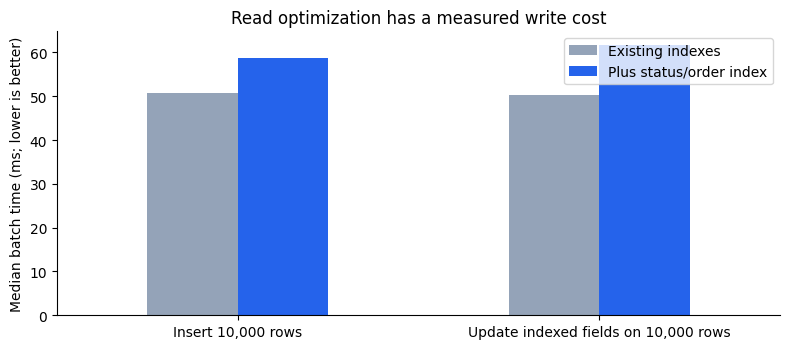

Added index: **404 KiB**. Median insertion cost **+16.0%**, indexed-column update cost **+22.6%**. Overall database allocation grew **476 KiB**, including free-page/layout effects. The next acceptance gate is zero issue/label row loads for unchanged recurring queries; it is not yet claimed by these two tasks.

In [16]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

implementation_dir = Path('/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019')
implementation_roots = json.loads((implementation_dir / 'list-issues-implementation-s1-s2.json').read_text())
index_cost = pd.DataFrame(implementation_roots['s1']['cost']['rows'])
index_medians = index_cost.groupby('indexed')[['insert_us', 'update_us', 'db_bytes', 'index_bytes']].median()
index_overheads = (index_medians.loc[True, ['insert_us', 'update_us']] / index_medians.loc[False, ['insert_us', 'update_us']] - 1) * 100
assert len(index_cost) == 10 and set(index_cost['sqlite']) == {'3.51.3'}
assert implementation_roots['s1']['red']['exit_code'] == 101
assert implementation_roots['s1']['green']['exit_code'] == 0
assert all(c['exit_code'] == 0 for c in implementation_roots['s2']['commands'] if c['phase'] in ('GREEN', 'CHECK'))
display(Markdown('''### TDD implementation evidence — index and tracing

The status/order index removes the temporary sorter in both tested single-status query plans. Fresh and existing connections, initialization, row contents, defined ordering and pagination windows are covered. The tracing change preserves caller ancestry across reader jobs and records query shape, phase durations and row counts; its focused suite passed **96 tests**.

These are the first two tasks in the implementation plan. Direct summaries, durable change tracking, selective reuse and incremental hygiene remain pending in this checkpoint. No new binary has been installed or sampled.

**Write-cost trade-off:** five alternating rounds on private file-backed SQLite 3.51.3 databases, WAL/NORMAL, 10,000 rows and 256-byte descriptions. Updates modify indexed columns on every row. These batch measurements are not typical single-issue edit latency and are not directly comparable with the earlier Python SQLite 3.53.1 read benchmark.'''))
index_table = index_medians.rename(index={False: 'Existing indexes', True: 'Plus status/order index'}).copy()
index_table['insert_ms_per_10000'] = index_table.pop('insert_us') / 1000
index_table['update_ms_per_10000'] = index_table.pop('update_us') / 1000
index_table['db_KiB'] = index_table.pop('db_bytes') / 1024
index_table['added_index_KiB'] = index_table.pop('index_bytes') / 1024
display(index_table.round(3))
fig, ax = plt.subplots(figsize=(8, 3.6))
plot_data = index_table[['insert_ms_per_10000', 'update_ms_per_10000']].T
plot_data.index = ['Insert 10,000 rows', 'Update indexed fields on 10,000 rows']
plot_data.plot.bar(ax=ax, rot=0, color=['#94a3b8', '#2563eb'])
ax.set_ylabel('Median batch time (ms; lower is better)')
ax.set_xlabel('')
ax.set_title('Read optimization has a measured write cost')
ax.legend(title='')
fig.tight_layout()
fig.savefig(implementation_dir / 'list-issues-implementation-index-cost.png', dpi=160)
display(fig)
plt.close(fig)
display(Markdown(f"Added index: **{index_medians.loc[True, 'index_bytes'] / 1024:.0f} KiB**. Median insertion cost **+{index_overheads['insert_us']:.1f}%**, indexed-column update cost **+{index_overheads['update_us']:.1f}%**. Overall database allocation grew **{(index_medians.loc[True, 'db_bytes'] - index_medians.loc[False, 'db_bytes']) / 1024:.0f} KiB**, including free-page/layout effects. The next acceptance gate is zero issue/label row loads for unchanged recurring queries; it is not yet claimed by these two tasks."))

In [18]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown

evidence_dir = Path("/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019/implementation-tdd")
s3 = json.loads((evidence_dir / "s3-summary.json").read_text())
assert s3["red"]["failed"] == 1 and s3["green"]["failed"] == 0
assert "summary must not decode unneeded due_at" in (evidence_dir / s3["red"]["log"]).read_text()
assert "104 passed; 0 failed; 1 ignored" in (evidence_dir / s3["green"]["log"]).read_text()
verification = pd.DataFrame([
    {"Check": "RED: unnecessary metadata decoding", "Passed": s3["red"]["passed"], "Failed": s3["red"]["failed"], "Interpretation": "Expected regression demonstrated"},
    {"Check": "GREEN: beads_crate focused suite", "Passed": s3["green"]["passed"], "Failed": s3["green"]["failed"], "Interpretation": "Passed; one manual benchmark ignored"},
])
display(Markdown("### S3: direct summary SQL verified\nSeven issue fields plus batched labels replace full 36-field Issue decoding. Description remains included."))
display(verification)
display(Markdown(
    f"RED commit: `{s3['red_commit'][:9]}`; implementation: `{s3['implementation_commit'][:9]}`. "
    "Independent review and production-library clippy passed. "
    "The differential oracle covers 1,800 filter/page combinations.\n\n"
    "**Contract:** " + s3["intentional_semantics"] + "\n\n"
    "**Limits:** This stage still queries SQLite on each call; change-feed and subscription work follow. "
    "Tests overlap earlier suites, so pass counts must not be added as unique tests. "
    "No new live-process speedup has been measured."
))


### S3: direct summary SQL verified
Seven issue fields plus batched labels replace full 36-field Issue decoding. Description remains included.

,Check,Passed,Failed,Interpretation
0,RED: unnecessary metadata decoding,4,1,Expected regression demonstrated
1,GREEN: beads_crate focused suite,104,0,Passed; one manual benchmark ignored


RED commit: `64f716b60`; implementation: `9f3eac7d4`. Independent review and production-library clippy passed. The differential oracle covers 1,800 filter/page combinations.

**Contract:** Decode only seven returned issue fields. Other metadata is not validated as Rust values. SQL uses unchanged stored sort/filter values; projected-column, SQL and label failures remain errors.

**Limits:** This stage still queries SQLite on each call; change-feed and subscription work follow. Tests overlap earlier suites, so pass counts must not be added as unique tests. No new live-process speedup has been measured.

In [19]:
import sqlite3
import tempfile
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown

# Private minimal SQLite reproduction; never opens the project's database.
refresh_sql = "SELECT EXISTS(SELECT 1 FROM sqlite_schema WHERE type='table' AND name='spur_issue_changes')"
trigger_sql = ("CREATE TRIGGER spur_issue_issues_update AFTER UPDATE ON issues "
               "BEGIN INSERT INTO spur_issue_changes VALUES (NEW.id); END")
probe_rows = []
for cache_size in (0, 128):
    for refresh_when in ("before-first-update", "after-failed-update"):
        with tempfile.TemporaryDirectory(prefix="spur-schema-probe-") as temp_dir:
            db_path = str(Path(temp_dir) / "probe.db")
            writer = sqlite3.connect(db_path, isolation_level=None, cached_statements=cache_size)
            feed = bystander = None
            try:
                writer.executescript(
                    "PRAGMA journal_mode=WAL;"
                    "CREATE TABLE issues(id TEXT PRIMARY KEY,description TEXT);"
                    "CREATE TABLE spur_issue_changes(issue_id TEXT);"
                    + trigger_sql + ";INSERT INTO issues VALUES('a','A'),('c','C');"
                )
                assert writer.execute(refresh_sql).fetchone() == (1,)
                feed = sqlite3.connect(db_path, isolation_level=None, cached_statements=cache_size)
                bystander = sqlite3.connect(db_path, isolation_level=None, cached_statements=cache_size)
                assert bystander.execute("SELECT count(*) FROM issues").fetchone() == (2,)
                assert feed.execute("SELECT count(*) FROM spur_issue_changes").fetchone() == (0,)
                writer.execute("DROP TABLE spur_issue_changes")
                assert feed.execute(refresh_sql).fetchone() == (0,)
                feed.executescript(
                    "BEGIN IMMEDIATE;DROP TRIGGER spur_issue_issues_update;"
                    "CREATE TABLE spur_issue_changes(issue_id TEXT);"
                    + trigger_sql + ";COMMIT;"
                )
                update_sql = "UPDATE issues SET description='after recovery' WHERE id='c'"
                initial_error = None
                failed_write_unchanged = None
                if refresh_when == "after-failed-update":
                    try:
                        writer.execute(update_sql)
                    except sqlite3.Error as error:
                        initial_error = str(error)
                    assert initial_error == "no such table: main.spur_issue_changes"
                    assert feed.execute("SELECT description FROM issues WHERE id='c'").fetchone() == ("C",)
                    assert feed.execute("SELECT count(*) FROM spur_issue_changes").fetchone() == (0,)
                    failed_write_unchanged = True
                # Refresh and retry on the SAME writer; no reconnect.
                assert writer.execute(refresh_sql).fetchone() == (1,)
                writer.execute(update_sql)
                assert feed.execute("SELECT description FROM issues WHERE id='c'").fetchone() == ("after recovery",)
                assert feed.execute("SELECT issue_id FROM spur_issue_changes").fetchall() == [("c",)]
                bystander.execute("UPDATE issues SET description='bystander' WHERE id='a'")
                assert feed.execute("SELECT issue_id FROM spur_issue_changes").fetchall() == [("c",), ("a",)]
                probe_rows.append({
                    "sqlite": sqlite3.sqlite_version,
                    "journal_mode": "WAL",
                    "cached_statements": cache_size,
                    "refresh_when": refresh_when,
                    "initial_error": initial_error,
                    "failed_write_unchanged": failed_write_unchanged,
                    "same_writer_tracked_retry": True,
                    "bystander_without_refresh": True,
                })
            finally:
                for connection in (bystander, feed, writer):
                    if connection is not None:
                        connection.close()

probe_result = {
    "kind": "minimal private SQLite schema-recovery reproduction",
    "rows": probe_rows,
    "limitations": [
        "Local Python SQLite version is reported per row; remote Rust-linked SQLite 3.51.3 needs separate test.",
        "Simplified two-table trigger fixture; this does not prove complete production feed behavior.",
        "No production database was opened and no live-process performance claim is made.",
    ],
    "references": [
        "https://www.sqlite.org/fileformat2.html#schema_cookie",
        "https://www.sqlite.org/c3ref/prepare.html",
    ],
}
probe_path = Path("/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019/implementation-tdd/s4-schema-recovery-probe.json")
probe_path.write_text(json.dumps(probe_result, indent=2) + "\n")
display(Markdown("### S4 review: recover the original SQLite writer\nA bounded metadata read restores this minimal fixture's writer after another connection repairs its journal. The failed write leaves data unchanged."))
display(pd.DataFrame(probe_rows))
display(Markdown(
    f"All **{len(probe_rows)} private cases passed** on Python SQLite **{sqlite3.sqlite_version}**. "
    "The writer connection was retained. A bystander connection also remained writable.\n\n"
    "**Limit:** This is a minimal local reproduction. The S4 revision must verify it on the Rust-linked SQLite version. "
    "The production feed remains under review. "
    "The inferred mechanism is that a successful database read reaches the schema-cookie check; "
    "[SQLite schema-cookie documentation](https://www.sqlite.org/fileformat2.html#schema_cookie) and "
    "[prepare/step behavior](https://www.sqlite.org/c3ref/prepare.html) describe that contract."
))


### S4 review: recover the original SQLite writer
A bounded metadata read restores this minimal fixture's writer after another connection repairs its journal. The failed write leaves data unchanged.

,sqlite,journal_mode,cached_statements,refresh_when,initial_error,failed_write_unchanged,same_writer_tracked_retry,bystander_without_refresh
0,3.53.1,WAL,0,before-first-update,NaN,None,True,True
1,3.53.1,WAL,0,after-failed-update,no such table: main.spur_issue_changes,True,True,True
2,3.53.1,WAL,128,before-first-update,NaN,None,True,True
3,3.53.1,WAL,128,after-failed-update,no such table: main.spur_issue_changes,True,True,True


All **4 private cases passed** on Python SQLite **3.53.1**. The writer connection was retained. A bystander connection also remained writable.

**Limit:** This is a minimal local reproduction. The S4 revision must verify it on the Rust-linked SQLite version. The production feed remains under review. The inferred mechanism is that a successful database read reaches the schema-cookie check; [SQLite schema-cookie documentation](https://www.sqlite.org/fileformat2.html#schema_cookie) and [prepare/step behavior](https://www.sqlite.org/c3ref/prepare.html) describe that contract.

In [20]:
from pathlib import Path
import re, ast, json
import pandas as pd
from IPython.display import display, Markdown
s4_dir = Path("/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019/implementation-tdd")
s4_review = json.loads((s4_dir / "s4-attempt-2-review.json").read_text())
s4_red = (s4_dir / "s4-attempt-2-red.log").read_text()
s4_green = (s4_dir / "s4-attempt-2-green3.log").read_text()
assert "0 passed; 1 failed" in s4_red and "23 passed; 0 failed" in s4_green
s4_work = []
for size, tuples in re.findall(r"watermark/delta work size=(\d+): (.+?) \(rows, vm, fullscan, sorts\)", s4_green):
    for query, counts in zip(["watermark", "unchanged delta"], ast.literal_eval(tuples)):
        s4_work.append(dict(issue_rows=int(size), query=query, returned_rows=counts[0], vm_steps=counts[1], fullscan_steps=counts[2], sort_operations=counts[3]))
s4_work = pd.DataFrame(s4_work)
assert len(s4_work) == 6 and (s4_work.fullscan_steps == 0).all()
assert s4_work.groupby("query").vm_steps.nunique().eq(1).all()
display(Markdown("### Durable change feed: approved TDD checkpoint\nReal adapter comment RED → **23/23 GREEN**; independent review and strict production-library Clippy passed. SQLite **3.51.3**."))
display(s4_work)
display(Markdown("Counters cover the **shared production watermark and delta SQL**, not whole-request timings. Work stayed fixed across 3, 300 and 3,000 issue rows. Metadata/trigger validation cost still needs the integrated latency benchmark. An empty delta invokes one sort operation with no full-scan steps.\n\nSummary, timestamp and comment revisions are retained independently. Real comment insertion does not invalidate plain summaries; since-filtered consumers must also consider timestamps. Recovery, trigger restoration, hidden-rowid replacement and serialized-cursor/file replacement regressions pass.\n\n**Stage:** change feed approved; query reuse and incremental hygiene remain in progress. The live SPUR binary has not changed. Solver checks cover bounded declared policies, not complete Rust/SQLite correctness or performance."))


### Durable change feed: approved TDD checkpoint
Real adapter comment RED → **23/23 GREEN**; independent review and strict production-library Clippy passed. SQLite **3.51.3**.

,issue_rows,query,returned_rows,vm_steps,fullscan_steps,sort_operations
0,3,watermark,1,54,0,0
1,3,unchanged delta,0,16,0,1
2,300,watermark,1,54,0,0
3,300,unchanged delta,0,16,0,1
4,3000,watermark,1,54,0,0
5,3000,unchanged delta,0,16,0,1


Counters cover the **shared production watermark and delta SQL**, not whole-request timings. Work stayed fixed across 3, 300 and 3,000 issue rows. Metadata/trigger validation cost still needs the integrated latency benchmark. An empty delta invokes one sort operation with no full-scan steps.

Summary, timestamp and comment revisions are retained independently. Real comment insertion does not invalidate plain summaries; since-filtered consumers must also consider timestamps. Recovery, trigger restoration, hidden-rowid replacement and serialized-cursor/file replacement regressions pass.

**Stage:** change feed approved; query reuse and incremental hygiene remain in progress. The live SPUR binary has not changed. Solver checks cover bounded declared policies, not complete Rust/SQLite correctness or performance.

In [21]:
# Aggregate payload sizes from the existing private profiling backup only.
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown
assert "probe_db" in globals(), "Run the existing private-backup cell first"
s5_payload_rows = []
s5_text_columns = ["id","title","description","status","issue_type","assignee","created_at"]
s5_payload_expr = " + ".join(f"length(CAST(COALESCE({col},'') AS BLOB))" for col in s5_text_columns)
for shape, predicate in [
    ("open_unpaginated", "status='open' AND (is_template=0 OR is_template IS NULL)"),
    ("all_non_template", "(is_template=0 OR is_template IS NULL)")
]:
    count, payload, max_payload = probe_db.execute(
        f"SELECT count(*),coalesce(sum({s5_payload_expr}),0),coalesce(max({s5_payload_expr}),0) FROM issues WHERE {predicate}"
    ).fetchone()
    label_count, label_bytes = probe_db.execute(
        f"SELECT count(*),coalesce(sum(length(CAST(labels.label AS BLOB))),0) FROM labels JOIN issues ON issues.id=labels.issue_id WHERE {predicate}"
    ).fetchone()
    s5_payload_rows.append(dict(shape=shape, issue_rows=count, string_bytes=payload, label_rows=label_count, label_string_bytes=label_bytes, string_total_bytes=payload+label_bytes, largest_row_string_bytes=max_payload))
s5_budget_probe = dict(
    source="existing consistent private backup from original profiling; no live database opened",
    captured_utc=schema_probe["captured_utc"],
    rows=s5_payload_rows,
    limitations="UTF-8 payload lower bound only; excludes Rust structs, allocations/capacity, maps, duplicate keys, source/url strings and staged/output copies. Not an exact cache-admission or memory benchmark."
)
s5_budget_path = Path("/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019/implementation-tdd/s5-payload-budget-probe.json")
s5_budget_path.write_text(json.dumps(s5_budget_probe, indent=2)+"\n")
display(Markdown("### Representative cache payload sizing\nAggregates from the original private profiling backup; no issue contents displayed."))
display(pd.DataFrame(s5_payload_rows))
display(Markdown(s5_budget_probe["limitations"]))


### Representative cache payload sizing
Aggregates from the original private profiling backup; no issue contents displayed.

,shape,issue_rows,string_bytes,label_rows,label_string_bytes,string_total_bytes,largest_row_string_bytes
0,open_unpaginated,396,464630,943,27013,491643,6173
1,all_non_template,2331,3598859,9674,340205,3939064,9217


UTF-8 payload lower bound only; excludes Rust structs, allocations/capacity, maps, duplicate keys, source/url strings and staged/output copies. Not an exact cache-admission or memory benchmark.

In [23]:
from pathlib import Path
import json, copy
import pandas as pd
from IPython.display import display, Markdown
s5_model_path = Path("/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019/implementation-tdd/s5-jev-review-policy.json")
s5_model = json.loads(s5_model_path.read_text())
s5_cases = []
for case in s5_model["cases"]:
    request = copy.deepcopy(s5_model["base_request"])
    recipe = case["request_recipe"]
    if "horizon" in recipe:
        facts = request["facts"]
        facts["horizon"] = recipe["horizon"]
        facts["enabled_transitions"] = [t for t in facts["enabled_transitions"] if t["step"] < recipe["keep_transitions_with_step_less_than"]]
        trace = facts["traces"]["issue_list"]
        trace["states"] = trace["states"][:recipe["truncate_states_to"]]
        trace["events"] = trace["events"][:recipe["truncate_events_to"]]
        trace["states"][-1] = recipe["replace_final_state"]
    facts = request["facts"]
    trace = facts["traces"]["issue_list"]
    allowed = {(t["step"], t["from"], t["event"], t["to"]) for t in facts["enabled_transitions"]}
    transition_ok = all((i, trace["states"][i], event, trace["states"][i+1]) in allowed for i,event in enumerate(trace["events"]))
    initial_ok = trace["states"][0] in facts["initial_states"]
    safe_ok = all(state in facts["safe_states"] for state in trace["states"])
    python_pass = transition_ok and initial_ok and safe_ok
    expected = case["name"] == "intended"
    assert python_pass == expected
    assert case["result"]["status"] == ("sat" if expected else "unsat")
    assert case["result"]["outcome"] == ("pass" if expected else "fail")
    s5_cases.append(dict(scenario=case["name"], steps=facts["horizon"], z3=case["result"]["status"], verdict=case["result"]["outcome"], python_matches=True, solve_id=case["result"]["solve_id"]))
s5_red_text = (s5_model_path.parent / "s5-review-red.log").read_text()
assert "11 passed; 7 failed" in s5_red_text
display(Markdown(f"### Cache review policy — Jev and Python cross-check\nJev gate **{s5_model['jev_output']['gate']}**, weakest confidence **{s5_model['jev_output']['provenance']['weakest']}**. The intended 35-step trace passes; ten deliberately invalid trace prefixes fail. Python independently reproduces the catalog transition, initial-state and safe-state checks."))
display(pd.DataFrame(s5_cases))
display(Markdown("The new Rust regressions first produced **11 existing passes / 7 expected failures**, covering discarded candidates and bypass accounting.\n\n**Implementation correspondence:** " + s5_model["candidate_review"]["source_match"] + "\n\n" + s5_model["candidate_review"]["limitations"]))


### Cache review policy — Jev and Python cross-check
Jev gate **open**, weakest confidence **0.89**. The intended 35-step trace passes; ten deliberately invalid trace prefixes fail. Python independently reproduces the catalog transition, initial-state and safe-state checks.

,scenario,steps,z3,verdict,python_matches,solve_id
0,intended,35,sat,pass,True,sol_c300d8193d0d450b
1,unchanged_full_load,3,unsat,fail,True,sol_671a07402275430e
2,unrelated_full_load,4,unsat,fail,True,sol_6a19e9ee04034011
3,relevant_full_load,6,unsat,fail,True,sol_105d7e3abffe49a4
4,race_published_current,7,unsat,fail,True,sol_bfecd2ad671b4759
5,over_budget_retained,19,unsat,fail,True,sol_2dd99ee53b6148e4
6,unsupported_order_retained,21,unsat,fail,True,sol_f4467df996a147fd
7,validation_reset_returned_dirty,23,unsat,fail,True,sol_38a1a27d4c534f2b
8,validation_error_swallowed,28,unsat,fail,True,sol_d263a0e4fe9e44f0
9,replacement_returned_dirty,33,unsat,fail,True,sol_52731db219344447


The new Rust regressions first produced **11 existing passes / 7 expected failures**, covering discarded candidates and bypass accounting.

**Implementation correspondence:** Approved S5 implementation1a569e5fc045e2ae81f1cd45ddbf032b5ba584c8 (captured fe7ac7f2f18dfbb8cc6620be742ee4c7dab676ec): independent review passed,18/18 focused GREEN after7behavioral RED failures, strict production-lib clippy/fmt passed. S7 integrated performance measurements remain pending.

Caller-normalized finite traces only. Does not prove Rust, SQLite trigger completeness, all concurrent interleavings, ordering, heap allocation, unbounded liveness, or speedup. Numeric bypass counts and retained-byte values are not encoded by this root trace; runtime counter tests and separate bounded capacity checks provide that evidence.

In [24]:
# S6 hygiene policy / TDD checkpoint — declared policy is not source proof.
import json, re
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

s6_dir = Path("/Volumes/Projects/spur/docs/performance/2026-10-09-spur-64019/implementation-tdd")
s6_policy = json.loads((s6_dir / "s6-jev-hygiene-policy.json").read_text())
s6_rows = []
for case in s6_policy["cases"]:
    req = json.loads(json.dumps(s6_policy["base_request"]))
    recipe = case.get("recipe")
    facts = req["facts"]
    trace = facts["traces"]["hygiene"]
    if recipe:
        last = trace["events"].index(recipe["prefix_through_event"])
        facts["horizon"] = last + 1
        trace["events"] = trace["events"][:last + 1]
        trace["states"] = trace["states"][:last + 2]
        trace["states"][-1] = recipe["replace_last_state"]
        facts["enabled_transitions"] = [e for e in facts["enabled_transitions"] if e["step"] <= last]
    relation = {(e["step"], e["from"], e["event"], e["to"]) for e in facts["enabled_transitions"]}
    allowed = all((i, trace["states"][i], event, trace["states"][i+1]) in relation
                  for i, event in enumerate(trace["events"]))
    safe = all(state in facts["safe_states"] for state in trace["states"])
    initial = trace["states"][0] in facts["initial_states"]
    python_outcome = "pass" if allowed and safe and initial else "fail"
    result = case["result"]
    assert python_outcome == case["expected"] == result["outcome"]
    s6_rows.append({"case": case["name"], "steps": facts["horizon"],
                    "Python": python_outcome, "Z3": result["outcome"], "solve_id": result["solve_id"]})
display(Markdown("### S6 incremental hygiene checkpoint\n"
                 + s6_policy["candidate_review"]["source_match"] + "\n\n"
                 + s6_policy["candidate_review"]["limits"]))
display(pd.DataFrame(s6_rows))
s6_red_rows = []
for label, filename in [("core hygiene", "s6-red-core.log"), ("feed structural changes", "s6-red-pm.log")]:
    log = (s6_dir / filename).read_text()
    match = re.search(r"test result: (\w+)\. (\d+) passed; (\d+) failed; (\d+) ignored", log)
    assert match, filename
    s6_red_rows.append({"suite": label, "result": match[1], "passed": int(match[2]),
                       "failed": int(match[3]), "ignored": int(match[4])})
display(pd.DataFrame(s6_red_rows))
display(Markdown("The earlier compiler/fixture errors are preserved separately and do not count as behavioral RED. "
                 "The combined partial-failure/concurrent-write core test still needs the independent review refinements. "
                 "This checkpoint contains no new latency or live-process measurements."))


### S6 incremental hygiene checkpoint
Pending S6 implementation and independent review.

26-step supplied symbolic trace with 116 caller-declared enabled edges. No numeric cursor/clock, Rust execution, SQL isolation, exhaustive interleaving, memory or latency proof. Event names express intended policy; runtime tests must establish that source performs those events.

,case,steps,Python,Z3,solve_id
0,declared_lifecycle,26,pass,pass,sol_0cb40a3910024041
1,unchanged_full_scan,3,fail,fail,sol_eb9517722b934ad4
2,partial_failure_acknowledged,5,fail,fail,sol_e62834f19e9f47dc
3,cancellation_acknowledged,7,fail,fail,sol_be6295add8774fb0
4,concurrent_comment_lost,10,fail,fail,sol_9c38e2cf9895402d
5,pending_candidate_dropped,13,fail,fail,sol_42eb26037b2a4cc3
6,deadline_skipped,14,fail,fail,sol_1de77138ff2f4802
7,parent_change_ignored,16,fail,fail,sol_3a67e58e9c3d4912
8,membership_exit_ignored,18,fail,fail,sol_76e1711e37724afa
9,timers_skipped,20,fail,fail,sol_e26709a8e738486e


,suite,result,passed,failed,ignored
0,core hygiene,FAILED,0,3,0
1,feed structural changes,FAILED,22,3,0


The earlier compiler/fixture errors are preserved separately and do not count as behavioral RED. The combined partial-failure/concurrent-write core test still needs the independent review refinements. This checkpoint contains no new latency or live-process measurements.